In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [45]:
df = pd.read_csv("/content/drive/MyDrive/Github/Telco Churn/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [46]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


# Customer Churn Prediction Using Machine Learning

## Project Overview

Customer churn occurs when customers stop using a company’s services. In the telecommunications industry, churn reduces recurring revenue and increases the cost of acquiring new customers. This project uses machine learning to identify customers who are likely to cancel their telecom service.

The project will analyze customer demographics, subscription services, contract types, billing information, payment methods, and charges to understand the main factors related to churn.

---

## Business Problem

A telecom company wants to reduce the number of customers who leave its services. The company needs a data-driven method to identify customers who are at high risk of churn before they cancel their service.

By predicting churn early, the company can take proactive actions such as:

- Offering discounts or loyalty benefits
- Encouraging customers to select long-term contracts
- Providing better technical support
- Offering service bundles or personalized plans
- Contacting high-risk customers with retention campaigns

---

## Project Objective

The main objective of this project is to build and evaluate machine-learning models that predict whether a telecom customer will churn.

The project will answer two major questions:

1. Which customer characteristics, services, and account details are associated with churn?
2. Can a machine-learning model accurately identify customers who are likely to churn?

The final model will also be explained using SHAP values so that the business can understand the most important churn drivers.

---

## Dataset Overview

**Dataset Name:** Telco Customer Churn Dataset  
**Source:** Kaggle / IBM Sample Dataset  
**Number of Rows:** 7,043 customer records  
**Number of Columns:** 21 columns  
**Unit of Analysis:** One row represents one telecom customer  
**Machine Learning Problem:** Supervised Binary Classification  

The dataset includes customer demographic information, account details, service subscriptions, billing information, and churn status.

The target variable is:

- `Churn`
  - `Yes` = Customer left the telecom company
  - `No` = Customer remained with the telecom company

---

## Dataset Columns

| Category | Columns | Description |
|---|---|---|
| Customer Identifier | `customerID` | Unique identifier for each customer |
| Demographics | `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Customer personal and household information |
| Customer Relationship | `tenure` | Number of months the customer has stayed with the company |
| Phone Services | `PhoneService`, `MultipleLines` | Phone subscription and multiple-line information |
| Internet Services | `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Internet plan and service add-ons |
| Account Information | `Contract`, `PaperlessBilling`, `PaymentMethod` | Customer contract, billing, and payment details |
| Billing Information | `MonthlyCharges`, `TotalCharges` | Monthly and total amount charged to the customer |
| Target Variable | `Churn` | Indicates whether a customer left the company |

---

## Data Types in the Dataset

| Column | Data Type | Data Category |
|---|---|---|
| `customerID` | object | Unique customer identifier |
| `gender` | object | Categorical |
| `SeniorCitizen` | int64 | Binary numeric value: 0 or 1 |
| `Partner` | object | Categorical |
| `Dependents` | object | Categorical |
| `tenure` | int64 | Numeric |
| `PhoneService` | object | Categorical |
| `MultipleLines` | object | Categorical |
| `InternetService` | object | Categorical |
| `OnlineSecurity` | object | Categorical |
| `OnlineBackup` | object | Categorical |
| `DeviceProtection` | object | Categorical |
| `TechSupport` | object | Categorical |
| `StreamingTV` | object | Categorical |
| `StreamingMovies` | object | Categorical |
| `Contract` | object | Categorical |
| `PaperlessBilling` | object | Categorical |
| `PaymentMethod` | object | Categorical |
| `MonthlyCharges` | float64 | Numeric |
| `TotalCharges` | object | Should be converted to numeric |
| `Churn` | object | Target variable |

---

## Important Data Preparation Decisions

Before building machine-learning models, the following decisions will be made:

1. **Remove `customerID` from model features**
   - `customerID` is only a unique identifier.
   - It does not represent customer behavior and should not be used for prediction.

2. **Convert `TotalCharges` from object to numeric**
   - `TotalCharges` represents the total amount paid by a customer.
   - It is currently stored as `object` because some rows may have blank spaces.
   - Blank values will be converted to missing values and handled using imputation.

3. **Convert `Churn` into binary numeric format**
   - `No` will become `0`.
   - `Yes` will become `1`.

4. **Keep categorical columns as categories**
   - Columns such as `Contract`, `PaymentMethod`, and `InternetService` will remain categorical.
   - They will be converted using One-Hot Encoding during preprocessing.

5. **Handle missing values safely**
   - Numeric missing values, especially in `TotalCharges`, will be handled using `IterativeImputer`.
   - Categorical missing values will be filled using the most frequent value.

6. **Split the data into training and testing data**
   - 80% of the data will be used for training.
   - 20% of the data will be used for testing.
   - Stratified splitting will preserve the churn proportion in both groups.

7. **Handle class imbalance**
   - The churn variable may have more non-churn customers than churn customers.
   - SMOTE will be applied only to the training dataset.
   - SMOTE will not be applied to the test dataset to prevent data leakage.

---

## Questions This Dataset Can Answer

### Customer Churn Questions

1. What percentage of telecom customers churn?

2. Which contract type has the highest churn rate?

3. Do customers with month-to-month contracts churn more than customers with one-year or two-year contracts?

4. Do new customers with low tenure churn more than long-term customers?

5. Which payment method has the highest customer churn rate?

6. Does paperless billing relate to customer churn?

7. Does internet service type affect churn?

8. Do customers with fiber optic internet churn more or less than customers with DSL internet?

9. Does technical support reduce customer churn?

10. Do customers with online security, online backup, or device protection churn less often?

11. Are higher monthly charges associated with higher churn?

12. How do total charges differ between customers who churn and those who remain?

13. Are senior citizens more likely to churn?

14. Does having a partner or dependents relate to churn behavior?

15. Which customer features are the strongest predictors of churn?

---

## Machine Learning Questions

1. Can machine learning predict whether a customer will churn?

2. Which model gives the best churn prediction performance?

3. Does SMOTE improve the ability to identify churn customers?

4. Which model has the best ROC-AUC score?

5. Which model has the highest recall for churn customers?

6. Which model gives the best balance between precision and recall?

7. What are the top five features driving churn predictions?

8. Which customers should be prioritized for retention campaigns?

---

## Machine Learning Models to Compare

The following models will be trained and compared:

1. **Logistic Regression**
   - Baseline model
   - Easy to interpret
   - Useful for understanding the initial relationship between features and churn

2. **Decision Tree Classifier**
   - Creates simple decision rules
   - Can capture non-linear patterns
   - Easy to visualize but can overfit

3. **Random Forest Classifier**
   - Uses multiple decision trees
   - Usually provides stronger and more stable predictions than one decision tree
   - Can show feature importance

4. **XGBoost Classifier**
   - Advanced gradient-boosting model
   - Often performs well on structured business datasets
   - Can capture complex churn patterns

---

## Model Evaluation Metrics

The models will not be evaluated using accuracy alone because churn data may be imbalanced.

The following metrics will be used:

| Metric | Purpose |
|---|---|
| Accuracy | Overall percentage of correct predictions |
| Precision | Among customers predicted to churn, how many actually churned |
| Recall | Among actual churn customers, how many were correctly identified |
| F1-Score | Balance between precision and recall |
| ROC-AUC Score | Ability to distinguish churn and non-churn customers |
| Average Precision | Performance using the precision-recall relationship |
| Confusion Matrix | Shows true positives, true negatives, false positives, and false negatives |
| ROC Curve | Visual comparison of model discrimination performance |
| Precision-Recall Curve | Useful for evaluating imbalanced churn data |

The final model will be selected primarily using ROC-AUC, recall, F1-score, and business usefulness.

---

## Validation and Optimization Plan

The project will use:

- **Train-test split:** 80% training and 20% testing data
- **Stratified sampling:** To preserve churn proportions
- **SMOTE:** To address class imbalance in training data
- **5-Fold Stratified Cross-Validation:** To validate models reliably
- **GridSearchCV:** To identify the best hyperparameters for Random Forest and XGBoost

SMOTE will be used only inside the training pipeline and cross-validation process. This prevents data leakage into the test set.

---

## Model Explainability Plan

The final model will be explained using **SHAP (SHapley Additive exPlanations)** values.

SHAP analysis will help answer:

- Which variables increase churn risk?
- Which variables reduce churn risk?
- What are the top five churn drivers?
- Why did the model predict that a specific customer is likely to churn?

This makes the machine-learning model more transparent and useful for business decision-making.

---

## Initial Business Hypotheses

The following are hypotheses that will be tested during exploratory data analysis. These are not final conclusions.

- Customers with month-to-month contracts may have higher churn rates.
- Customers with short tenure may be more likely to churn.
- Customers with higher monthly charges may be more likely to churn.
- Customers without technical support may have higher churn risk.
- Customers without online security, backup, or device protection may be more likely to leave.
- Internet service type may influence churn.
- Payment method may be associated with churn behavior.
- Customers using electronic check payment may have different churn behavior than customers using automatic payments.
- Customers with partners or dependents may have different retention behavior.

---

## Expected Project Deliverables

At the end of this project, the following deliverables will be created:

- Cleaned and prepared customer churn dataset
- Exploratory data analysis charts
- Churn rate analysis by contract type, tenure, payment method, and services
- Machine-learning model comparison table
- Hyperparameter tuning results using GridSearchCV
- ROC curve and Precision-Recall curve
- Confusion matrix for the final model
- SHAP feature importance charts
- Top five churn drivers
- Business recommendations to reduce churn
- GitHub README file documenting the complete project

---

## Project Scope and Limitations

This dataset can identify patterns associated with churn and predict which customers may be at risk. However, the analysis cannot prove that one feature directly causes churn.

For example, if month-to-month contract customers have higher churn, it does not prove that the contract type alone caused customers to leave. Other factors such as price, satisfaction, customer service experience, competitor offers, or personal circumstances may also influence churn.

The dataset does not include customer satisfaction scores, complaints, call-center interactions, competitor data, detailed promotion history, or specific reasons why customers cancelled. Therefore, the final recommendations will be data-informed actions that the business should test and monitor.

##STEP 1: INITIAL DATA UNDERSTANDING AND CLEANING

In [47]:
# ============================================================
# STEP 1: INITIAL DATA UNDERSTANDING AND CLEANING
# ============================================================

# Create a separate working copy of the original dataset.
# This protects the original df in case we need to compare or restart later.
data = df.copy()

# ------------------------------------------------------------
# 1. Dataset shape
# ------------------------------------------------------------
# Shows how many rows (customers) and columns (variables) are available.
print("Dataset Shape:")
print(f"Rows (customers): {data.shape[0]}")
print(f"Columns (variables): {data.shape[1]}")

# ------------------------------------------------------------
# 2. Preview the first five customer records
# ------------------------------------------------------------
# Helps confirm that the file loaded correctly and shows example values.
print("\nFirst Five Rows:")
display(data.head())

# ------------------------------------------------------------
# 3. Display column names
# ------------------------------------------------------------
# Helps confirm that all expected columns are available.
print("\nColumn Names:")
print(list(data.columns))

# ------------------------------------------------------------
# 4. Display data types
# ------------------------------------------------------------
# Important before cleaning because it identifies numeric,
# categorical, identifier, and incorrectly typed columns.
print("\nData Types:")
display(data.dtypes.to_frame(name="Data Type"))

# ------------------------------------------------------------
# 5. Check for missing values
# ------------------------------------------------------------
# The dataset may show zero missing values at this stage because
# blank spaces in TotalCharges are stored as text, not as NaN.
print("\nMissing Values Before Cleaning:")
missing_before = data.isnull().sum().sort_values(ascending=False)
display(missing_before[missing_before > 0].to_frame(name="Missing Values"))

# ------------------------------------------------------------
# 6. Check for duplicate customer records
# ------------------------------------------------------------
# Duplicate records can bias analysis and model results.
duplicate_count = data.duplicated().sum()

print(f"\nDuplicate Rows Found: {duplicate_count}")

# Remove duplicate rows only if they exist.
if duplicate_count > 0:
    data = data.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

# ------------------------------------------------------------
# 7. Inspect TotalCharges before converting it
# ------------------------------------------------------------
# TotalCharges should be numeric, but it is currently stored as object.
# Blank spaces in this column must be converted to missing values.
print("\nTotalCharges Data Type Before Conversion:")
print(data["TotalCharges"].dtype)

blank_total_charges = (
    data["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(f"Blank values found in TotalCharges: {blank_total_charges}")

# ------------------------------------------------------------
# 8. Convert TotalCharges from object to numeric
# ------------------------------------------------------------
# errors='coerce' changes blank or invalid values into NaN.
# These missing values will later be handled inside the ML preprocessing pipeline.
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

print("\nTotalCharges Data Type After Conversion:")
print(data["TotalCharges"].dtype)

print(f"Missing values in TotalCharges after conversion: {data['TotalCharges'].isnull().sum()}")

# ------------------------------------------------------------
# 9. Convert the target variable Churn to binary numeric format
# ------------------------------------------------------------
# No = 0 means customer stayed.
# Yes = 1 means customer churned.
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("\nChurn Values After Conversion:")
display(data["Churn"].value_counts().sort_index().to_frame(name="Customer Count"))

print("\nChurn Percentage:")
display(
    (data["Churn"]
     .value_counts(normalize=True)
     .sort_index()
     .mul(100)
     .round(2)
     .to_frame(name="Percentage"))
)

# ------------------------------------------------------------
# 10. Final missing-value check
# ------------------------------------------------------------
# This check confirms whether TotalCharges conversion created missing values.
print("\nMissing Values After Initial Cleaning:")
missing_after = data.isnull().sum().sort_values(ascending=False)
display(missing_after[missing_after > 0].to_frame(name="Missing Values"))

# ------------------------------------------------------------
# 11. Final cleaned dataset summary
# ------------------------------------------------------------
print("\nFinal Dataset Summary:")
print(f"Rows after duplicate check: {data.shape[0]}")
print(f"Columns after cleaning: {data.shape[1]}")
print(f"Total missing values: {data.isnull().sum().sum()}")

print("\nFinal Data Types:")
display(data.dtypes.to_frame(name="Data Type"))

Dataset Shape:
Rows (customers): 7043
Columns (variables): 21

First Five Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:


,Data Type
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing Values Before Cleaning:


...

,Percentage
Churn,
0,73.46
1,26.54



Missing Values After Initial Cleaning:


,Missing Values
TotalCharges,11



Final Dataset Summary:
Rows after duplicate check: 7043
Columns after cleaning: 21
Total missing values: 11

Final Data Types:


,Data Type
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


##STEP 2: CREATE HELPER COLUMNS FOR EXPLORATORY DATA ANALYSIS

In [48]:
# ============================================================
# STEP 2: CREATE HELPER COLUMNS FOR EXPLORATORY DATA ANALYSIS
# ============================================================

# Create a separate copy for EDA.
# This allows us to create grouped categories for charts
# without changing the cleaned dataset that will later be used for modeling.
eda_data = data.copy()

# ------------------------------------------------------------
# 1. Create tenure groups
# ------------------------------------------------------------
# Tenure measures how many months a customer has stayed with the telecom company.
# Grouping tenure makes it easier to compare churn between new and long-term customers.
eda_data["TenureGroup"] = pd.cut(
    eda_data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

# ------------------------------------------------------------
# 2. Create monthly charge groups
# ------------------------------------------------------------
# MonthlyCharges is grouped into four pricing categories.
# This helps us examine whether customers with higher monthly bills churn more.
eda_data["MonthlyChargesGroup"] = pd.cut(
    eda_data["MonthlyCharges"],
    bins=[0, 35, 65, 95, np.inf],
    labels=[
        "Low Charges",
        "Medium Charges",
        "High Charges",
        "Very High Charges"
    ]
)

# ------------------------------------------------------------
# 3. Confirm that the new helper columns were created
# ------------------------------------------------------------
print("EDA helper columns created successfully.")

print("\nTenure Group Distribution:")
display(
    eda_data["TenureGroup"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame(name="Customer Count")
)

print("\nMonthly Charges Group Distribution:")
display(
    eda_data["MonthlyChargesGroup"]
    .value_counts(dropna=False)
    .sort_index()
    .to_frame(name="Customer Count")
)

# Display selected columns to confirm the grouping is correct.
print("\nPreview of EDA Dataset:")
display(
    eda_data[
        [
            "customerID",
            "tenure",
            "TenureGroup",
            "MonthlyCharges",
            "MonthlyChargesGroup",
            "Churn"
        ]
    ].head()
)

EDA helper columns created successfully.

Tenure Group Distribution:


,Customer Count
TenureGroup,
0-12 Months,2186
13-24 Months,1024
25-48 Months,1594
49-72 Months,2239



Monthly Charges Group Distribution:


,Customer Count
MonthlyChargesGroup,
Low Charges,1735
Medium Charges,1409
High Charges,2604
Very High Charges,1295



Preview of EDA Dataset:


,customerID,tenure,TenureGroup,MonthlyCharges,MonthlyChargesGroup,Churn
0,7590-VHVEG,1,0-12 Months,29.85,Low Charges,0
1,5575-GNVDE,34,25-48 Months,56.95,Medium Charges,0
2,3668-QPYBK,2,0-12 Months,53.85,Medium Charges,1
3,7795-CFOCW,45,25-48 Months,42.30,Medium Charges,0
4,9237-HQITU,2,0-12 Months,70.70,High Charges,1


##STEP 3: OVERALL CUSTOMER CHURN ANALYSIS

Customer Churn Summary:


,Churn Status,Customer Count,Percentage
0,No Churn,5174,73.46
1,Churn,1869,26.54


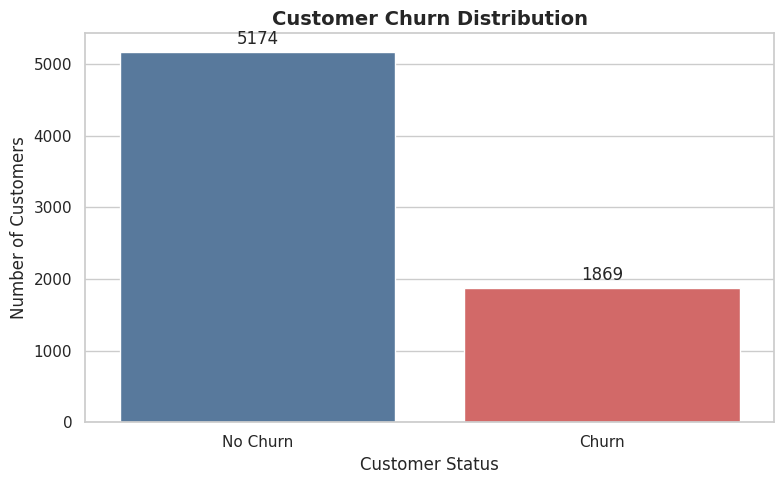

Overall Customer Churn Rate: 26.54%

Interpretation: This percentage represents the share of customers who cancelled their telecom service.


In [49]:
# ============================================================
# STEP 3: OVERALL CUSTOMER CHURN ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Calculate customer counts by churn status
# ------------------------------------------------------------
# Churn is already converted:
# 0 = Customer stayed
# 1 = Customer churned
churn_counts = eda_data["Churn"].value_counts().sort_index()

# Calculate the percentage of customers in each churn group.
churn_percentages = (
    eda_data["Churn"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Create a summary table for use in the notebook and GitHub README.
churn_summary = pd.DataFrame({
    "Churn Status": ["No Churn", "Churn"],
    "Customer Count": [
        churn_counts.get(0, 0),
        churn_counts.get(1, 0)
    ],
    "Percentage": [
        churn_percentages.get(0, 0),
        churn_percentages.get(1, 0)
    ]
})

print("Customer Churn Summary:")
display(churn_summary)

# ------------------------------------------------------------
# 2. Create churn distribution bar chart
# ------------------------------------------------------------
# This chart visually shows whether the dataset is imbalanced.
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=eda_data,
    x="Churn",
    hue="Churn",
    palette={0: "#4C78A8", 1: "#E45756"},
    legend=False
)

# Improve axis labels so they are understandable to a business audience.
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Churn", "Churn"])

plt.title(
    "Customer Churn Distribution",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

# Add the number of customers above each bar.
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Print the overall churn rate
# ------------------------------------------------------------
overall_churn_rate = eda_data["Churn"].mean() * 100

print(
    f"Overall Customer Churn Rate: {overall_churn_rate:.2f}%"
)

print(
    "\nInterpretation: This percentage represents the share of "
    "customers who cancelled their telecom service."
)

##STEP 4: CHURN RATE BY CONTRACT TYPE

Churn Summary by Contract Type:


,Contract,Total_Customers,Churned_Customers,Churn_Rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


TypeError: Figure.savefig() missing 1 required positional argument: 'fname'

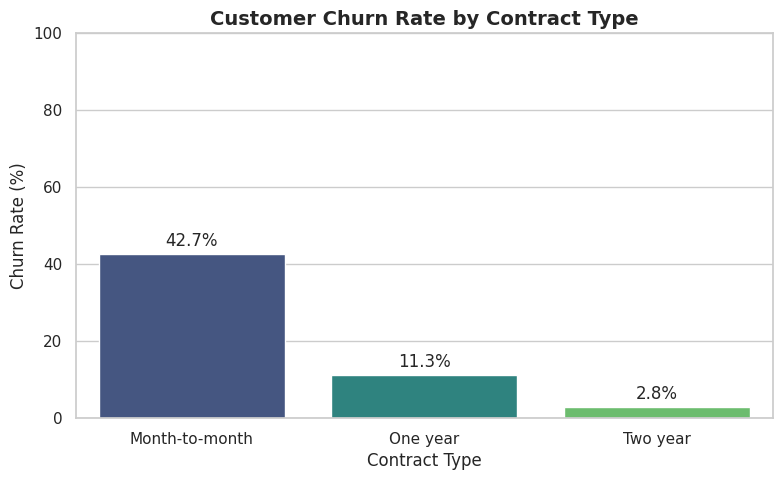

In [78]:
# ============================================================
# STEP 4: CHURN RATE BY CONTRACT TYPE
# ============================================================

# ------------------------------------------------------------
# Calculate customer count and churn rate for each contract type
# ------------------------------------------------------------
# Since Churn is coded as 0 and 1, the mean of Churn equals
# the churn rate for each contract group.
contract_churn_summary = (
    eda_data
    .groupby("Contract", observed=False)
    .agg(
        Total_Customers=("Churn", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

# Convert churn rate from decimal format to percentage format.
contract_churn_summary["Churn_Rate"] = (
    contract_churn_summary["Churn_Rate"] * 100
).round(2)

# Sort contract types from highest to lowest churn rate.
contract_churn_summary = contract_churn_summary.sort_values(
    by="Churn_Rate",
    ascending=False
)

print("Churn Summary by Contract Type:")
display(contract_churn_summary)

# ------------------------------------------------------------
# Create churn-rate bar chart by contract type
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_churn_summary,
    x="Contract",
    y="Churn_Rate",
    hue="Contract",
    palette="viridis",
    legend=False
)

plt.title(
    "Customer Churn Rate by Contract Type",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

# Add churn-rate percentage above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )
plt.savefig()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Identify the contract type with the highest churn rate
# ------------------------------------------------------------
highest_churn_contract = contract_churn_summary.iloc[0]

print(
    f"Highest Churn Contract Type: "
    f"{highest_churn_contract['Contract']}"
)

print(
    f"Churn Rate: "
    f"{highest_churn_contract['Churn_Rate']:.2f}%"
)

print(
    f"Churned Customers: "
    f"{int(highest_churn_contract['Churned_Customers'])} "
    f"out of {int(highest_churn_contract['Total_Customers'])}"
)
x

##STEP 5: CHURN RATE BY TENURE GROUP

Churn Summary by Tenure Group:


,TenureGroup,Total_Customers,Churned_Customers,Churn_Rate
0,0-12 Months,2186,1037,47.44
1,13-24 Months,1024,294,28.71
2,25-48 Months,1594,325,20.39
3,49-72 Months,2239,213,9.51


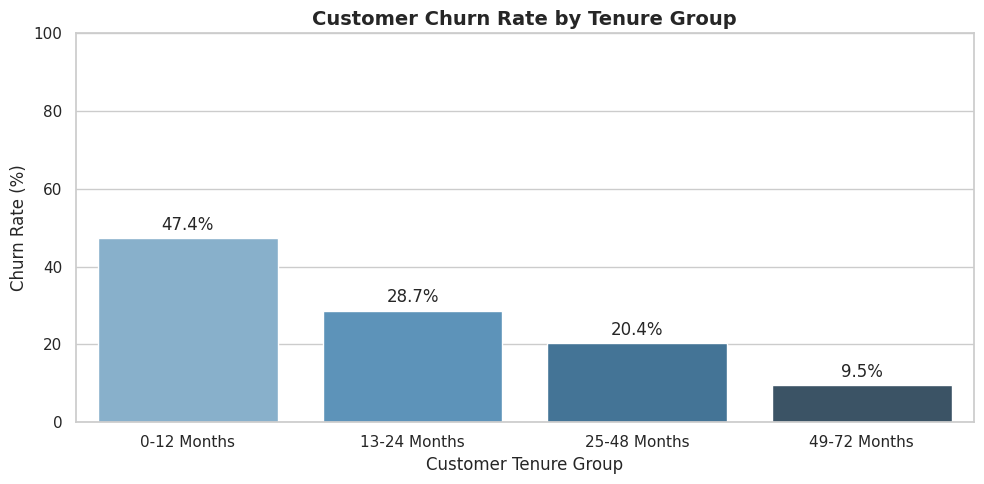

Highest Churn Tenure Group: 0-12 Months
Churn Rate: 47.44%
Churned Customers: 1037 out of 2186


In [51]:
# ============================================================
# STEP 5: CHURN RATE BY TENURE GROUP
# ============================================================

# ------------------------------------------------------------
# Calculate customer count and churn rate by tenure group
# ------------------------------------------------------------
# Churn is coded as:
# 0 = Customer did not churn
# 1 = Customer churned
#
# The average of the Churn column gives the churn rate for each group.
tenure_churn_summary = (
    eda_data
    .groupby("TenureGroup", observed=False)
    .agg(
        Total_Customers=("Churn", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

# Convert churn rate into percentage format.
tenure_churn_summary["Churn_Rate"] = (
    tenure_churn_summary["Churn_Rate"] * 100
).round(2)

print("Churn Summary by Tenure Group:")
display(tenure_churn_summary)

# ------------------------------------------------------------
# Create churn rate bar chart by tenure group
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=tenure_churn_summary,
    x="TenureGroup",
    y="Churn_Rate",
    hue="TenureGroup",
    palette="Blues_d",
    legend=False
)

plt.title(
    "Customer Churn Rate by Tenure Group",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Customer Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

# Add the churn rate above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Identify the tenure group with the highest churn rate
# ------------------------------------------------------------
highest_churn_tenure_group = tenure_churn_summary.loc[
    tenure_churn_summary["Churn_Rate"].idxmax()
]

print(
    f"Highest Churn Tenure Group: "
    f"{highest_churn_tenure_group['TenureGroup']}"
)

print(
    f"Churn Rate: "
    f"{highest_churn_tenure_group['Churn_Rate']:.2f}%"
)

print(
    f"Churned Customers: "
    f"{int(highest_churn_tenure_group['Churned_Customers'])} "
    f"out of {int(highest_churn_tenure_group['Total_Customers'])}"
)

##STEP 6: CHURN RATE BY PAYMENT METHOD

Churn Summary by Payment Method:


,PaymentMethod,Total_Customers,Churned_Customers,Churn_Rate
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


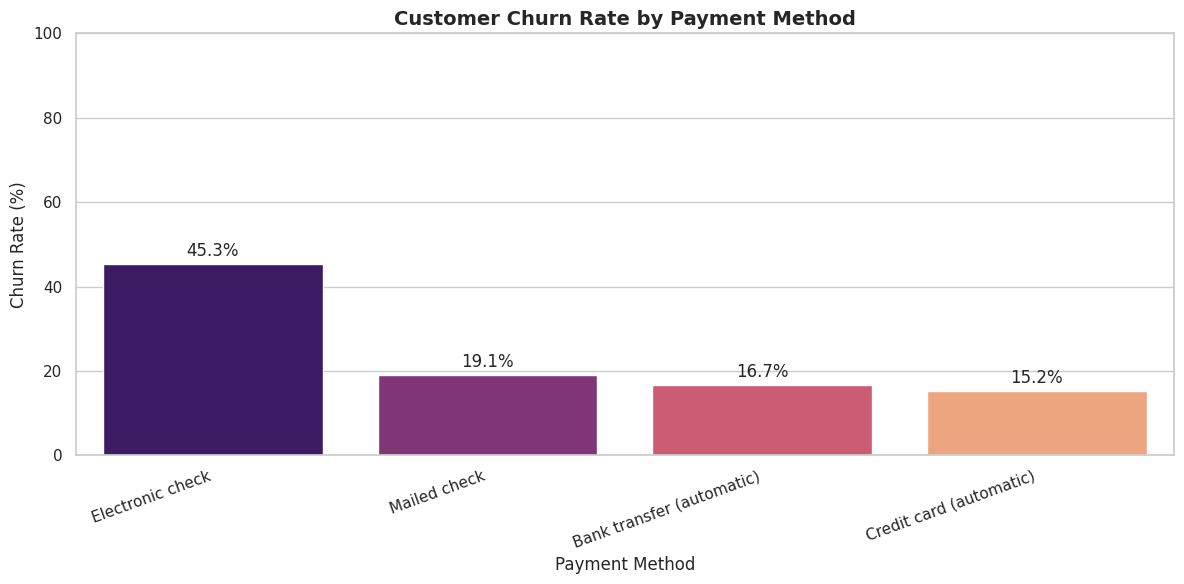

Highest Churn Payment Method: Electronic check
Churn Rate: 45.29%
Churned Customers: 1071 out of 2365


In [52]:
# ============================================================
# STEP 6: CHURN RATE BY PAYMENT METHOD
# ============================================================

# ------------------------------------------------------------
# Calculate customer count and churn rate by payment method
# ------------------------------------------------------------
# Churn is coded as:
# 0 = Customer did not churn
# 1 = Customer churned
#
# The average of Churn gives the churn rate for each payment method.
payment_churn_summary = (
    eda_data
    .groupby("PaymentMethod", observed=False)
    .agg(
        Total_Customers=("Churn", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

# Convert churn rate from decimal to percentage.
payment_churn_summary["Churn_Rate"] = (
    payment_churn_summary["Churn_Rate"] * 100
).round(2)

# Sort payment methods from highest to lowest churn rate.
payment_churn_summary = payment_churn_summary.sort_values(
    by="Churn_Rate",
    ascending=False
)

print("Churn Summary by Payment Method:")
display(payment_churn_summary)

# ------------------------------------------------------------
# Create churn-rate bar chart by payment method
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=payment_churn_summary,
    x="PaymentMethod",
    y="Churn_Rate",
    hue="PaymentMethod",
    palette="magma",
    legend=False
)

plt.title(
    "Customer Churn Rate by Payment Method",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

# Rotate labels so all payment method names are easy to read.
plt.xticks(rotation=20, ha="right")

# Add churn-rate percentages above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Identify payment method with the highest churn rate
# ------------------------------------------------------------
highest_churn_payment_method = payment_churn_summary.iloc[0]

print(
    f"Highest Churn Payment Method: "
    f"{highest_churn_payment_method['PaymentMethod']}"
)

print(
    f"Churn Rate: "
    f"{highest_churn_payment_method['Churn_Rate']:.2f}%"
)

print(
    f"Churned Customers: "
    f"{int(highest_churn_payment_method['Churned_Customers'])} "
    f"out of {int(highest_churn_payment_method['Total_Customers'])}"
)

##STEP 7: CHURN RATE BY INTERNET SERVICE TYPE

Churn Summary by Internet Service Type:


,InternetService,Total_Customers,Churned_Customers,Churn_Rate
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40


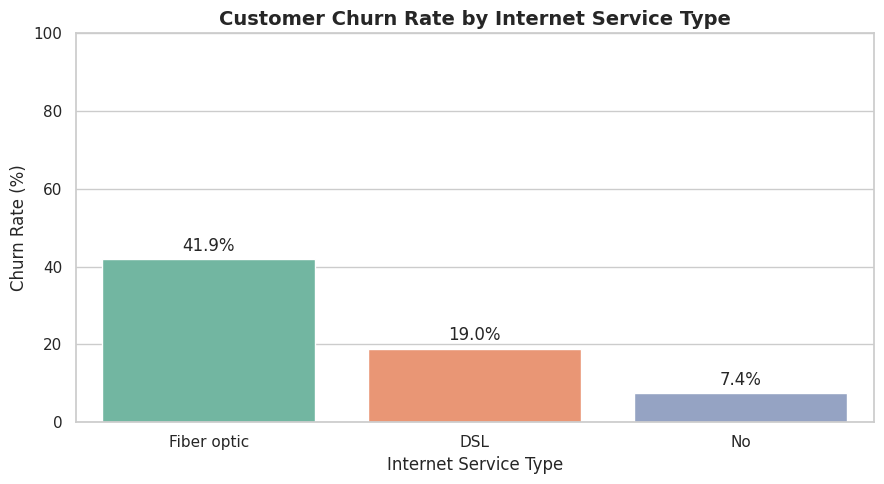

Highest Churn Internet Service Type: Fiber optic
Churn Rate: 41.89%
Churned Customers: 1297 out of 3096


In [53]:
# ============================================================
# STEP 7: CHURN RATE BY INTERNET SERVICE TYPE
# ============================================================

# ------------------------------------------------------------
# Calculate customer count and churn rate by internet service type
# ------------------------------------------------------------
# Churn is coded as:
# 0 = Customer did not churn
# 1 = Customer churned
#
# The mean of Churn gives the churn rate for each internet service group.
internet_churn_summary = (
    eda_data
    .groupby("InternetService", observed=False)
    .agg(
        Total_Customers=("Churn", "count"),
        Churned_Customers=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
    .reset_index()
)

# Convert churn rate into percentage format.
internet_churn_summary["Churn_Rate"] = (
    internet_churn_summary["Churn_Rate"] * 100
).round(2)

# Sort internet service groups from highest to lowest churn rate.
internet_churn_summary = internet_churn_summary.sort_values(
    by="Churn_Rate",
    ascending=False
)

print("Churn Summary by Internet Service Type:")
display(internet_churn_summary)

# ------------------------------------------------------------
# Create churn-rate bar chart by internet service type
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=internet_churn_summary,
    x="InternetService",
    y="Churn_Rate",
    hue="InternetService",
    palette="Set2",
    legend=False
)

plt.title(
    "Customer Churn Rate by Internet Service Type",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

# Add churn-rate percentage above each bar.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Identify internet service type with the highest churn rate
# ------------------------------------------------------------
highest_churn_internet_service = internet_churn_summary.iloc[0]

print(
    f"Highest Churn Internet Service Type: "
    f"{highest_churn_internet_service['InternetService']}"
)

print(
    f"Churn Rate: "
    f"{highest_churn_internet_service['Churn_Rate']:.2f}%"
)

print(
    f"Churned Customers: "
    f"{int(highest_churn_internet_service['Churned_Customers'])} "
    f"out of {int(highest_churn_internet_service['Total_Customers'])}"
)

##STEP 8: CHURN RATE BY SERVICE ADD-ONS

In [54]:
# ============================================================
# STEP 8: CHURN RATE BY SERVICE ADD-ONS
# ============================================================

# ------------------------------------------------------------
# Select the service add-on columns for analysis
# ------------------------------------------------------------
service_columns = [
    "TechSupport",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection"
]

# Create an empty list to store churn summaries for each service.
service_churn_results = []

# ------------------------------------------------------------
# Calculate churn rate for each service and subscription status
# ------------------------------------------------------------
for service in service_columns:

    # Group customers by their subscription status for the current service.
    # The mean of Churn gives the churn rate for each status.
    summary = (
        eda_data
        .groupby(service, observed=False)
        .agg(
            Total_Customers=("Churn", "count"),
            Churned_Customers=("Churn", "sum"),
            Churn_Rate=("Churn", "mean")
        )
        .reset_index()
    )

    # Rename the current service-status column to a common name.
    # This makes it possible to combine all service summaries into one table.
    summary = summary.rename(
        columns={service: "Subscription_Status"}
    )

    # Add the service name as a separate column.
    summary["Service"] = service

    # Convert the churn rate to a percentage.
    summary["Churn_Rate"] = (
        summary["Churn_Rate"] * 100
    ).round(2)

    # Save the result for this service.
    service_churn_results.append(summary)

# ------------------------------------------------------------
# Combine all service summaries into one table
# ------------------------------------------------------------
service_churn_summary = pd.concat(
    service_churn_results,
    ignore_index=True
)

# Arrange columns in a business-friendly order.
service_churn_summary = service_churn_summary[
    [
        "Service",
        "Subscription_Status",
        "Total_Customers",
        "Churned_Customers",
        "Churn_Rate"
    ]
]

# Sort the table from highest to lowest churn rate.
service_churn_summary = service_churn_summary.sort_values(
    by="Churn_Rate",
    ascending=False
)

print("Churn Summary by Service Add-On:")
display(service_churn_summary)

Churn Summary by Service Add-On:


,Service,Subscription_Status,Total_Customers,Churned_Customers,Churn_Rate
3,OnlineSecurity,No,3498,1461,41.77
0,TechSupport,No,3473,1446,41.64
6,OnlineBackup,No,3088,1233,39.93
9,DeviceProtection,No,3095,1211,39.13
11,DeviceProtection,Yes,2422,545,22.50
8,OnlineBackup,Yes,2429,523,21.53
2,TechSupport,Yes,2044,310,15.17
5,OnlineSecurity,Yes,2019,295,14.61
1,TechSupport,No internet service,1526,113,7.40
4,OnlineSecurity,No internet service,1526,113,7.40


##STEP 9: VISUALIZE CHURN RATE BY SERVICE ADD-ONS

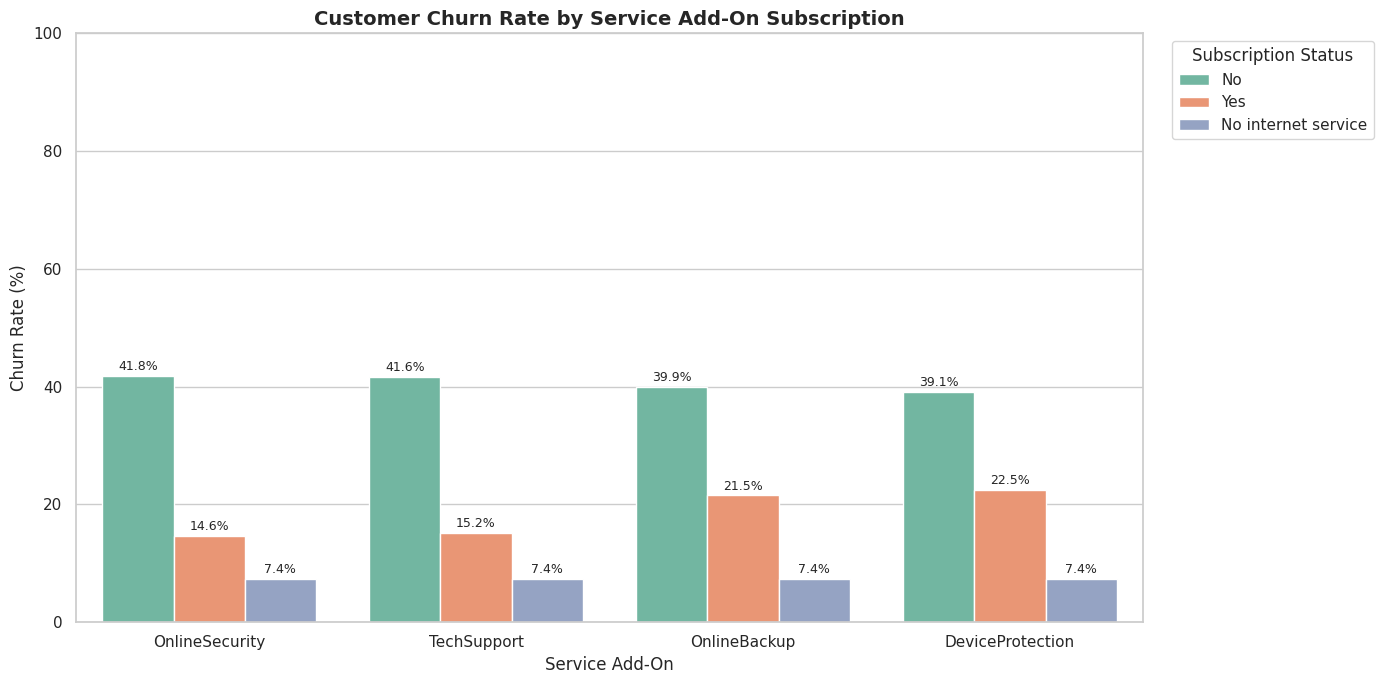

In [55]:
# ============================================================
# STEP 9: VISUALIZE CHURN RATE BY SERVICE ADD-ONS
# ============================================================

# Create a grouped bar chart.
# Each service will show churn rates for:
# Yes, No, and No internet service.
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=service_churn_summary,
    x="Service",
    y="Churn_Rate",
    hue="Subscription_Status",
    palette="Set2"
)

plt.title(
    "Customer Churn Rate by Service Add-On Subscription",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Service Add-On")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)

# Add percentage labels above bars.
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=2,
        fontsize=9
    )

# Place the legend outside the chart so it does not cover bars.
plt.legend(
    title="Subscription Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


##STEP 10: COMPARE CUSTOMERS WITH AND WITHOUT EACH SERVICE

In [56]:
# ============================================================
# STEP 10: COMPARE CUSTOMERS WITH AND WITHOUT EACH SERVICE
# ============================================================

# Keep only customers whose subscription status is Yes or No.
# Exclude "No internet service" because these customers cannot use
# internet-based support and protection services.
service_yes_no_summary = service_churn_summary[
    service_churn_summary["Subscription_Status"].isin(["Yes", "No"])
].copy()

# Display results sorted by service name and subscription status.
service_yes_no_summary = service_yes_no_summary.sort_values(
    by=["Service", "Subscription_Status"]
)

print("Churn Comparison: Customers With vs. Without Each Service:")
display(service_yes_no_summary)

# ------------------------------------------------------------
# Calculate churn-rate difference between Yes and No customers
# ------------------------------------------------------------
# This shows how much churn changes when customers have a service.
service_churn_comparison = (
    service_yes_no_summary
    .pivot(
        index="Service",
        columns="Subscription_Status",
        values="Churn_Rate"
    )
    .reset_index()
)

# Calculate difference:
# Positive difference means customers without the service churn more.
service_churn_comparison["Churn_Rate_Difference_No_minus_Yes"] = (
    service_churn_comparison["No"] -
    service_churn_comparison["Yes"]
).round(2)

# Sort from the biggest possible retention opportunity
# to the smallest.
service_churn_comparison = service_churn_comparison.sort_values(
    by="Churn_Rate_Difference_No_minus_Yes",
    ascending=False
)

print("Churn Rate Difference: Customers Without Service vs. With Service:")
display(service_churn_comparison)

Churn Comparison: Customers With vs. Without Each Service:


,Service,Subscription_Status,Total_Customers,Churned_Customers,Churn_Rate
9,DeviceProtection,No,3095,1211,39.13
11,DeviceProtection,Yes,2422,545,22.50
6,OnlineBackup,No,3088,1233,39.93
8,OnlineBackup,Yes,2429,523,21.53
3,OnlineSecurity,No,3498,1461,41.77
5,OnlineSecurity,Yes,2019,295,14.61
0,TechSupport,No,3473,1446,41.64
2,TechSupport,Yes,2044,310,15.17


Churn Rate Difference: Customers Without Service vs. With Service:


Subscription_Status,Service,No,Yes,Churn_Rate_Difference_No_minus_Yes
2,OnlineSecurity,41.77,14.61,27.16
3,TechSupport,41.64,15.17,26.47
1,OnlineBackup,39.93,21.53,18.40
0,DeviceProtection,39.13,22.50,16.63




## STEP 11: FINANCIAL ANALYSIS BY CHURN STATUS


In [57]:
# ============================================================
# STEP 11: FINANCIAL ANALYSIS BY CHURN STATUS
# ============================================================

# ------------------------------------------------------------
# Create readable churn labels for financial analysis
# ------------------------------------------------------------
# This creates a temporary text label:
# 0 = No Churn
# 1 = Churn
eda_data["ChurnStatus"] = eda_data["Churn"].map({
    0: "No Churn",
    1: "Churn"
})

# ------------------------------------------------------------
# Calculate financial summary statistics by churn status
# ------------------------------------------------------------
# The table compares average, median, minimum, and maximum
# monthly and total charges for churned vs. retained customers.
financial_churn_summary = (
    eda_data
    .groupby("ChurnStatus", observed=False)
    .agg(
        Customer_Count=("Churn", "count"),
        Average_Monthly_Charges=("MonthlyCharges", "mean"),
        Median_Monthly_Charges=("MonthlyCharges", "median"),
        Average_Total_Charges=("TotalCharges", "mean"),
        Median_Total_Charges=("TotalCharges", "median"),
        Average_Tenure=("tenure", "mean")
    )
    .reset_index()
)

# Round financial values for readability.
financial_churn_summary = financial_churn_summary.round(2)

print("Financial Summary by Churn Status:")
display(financial_churn_summary)

Financial Summary by Churn Status:


,ChurnStatus,Customer_Count,Average_Monthly_Charges,Median_Monthly_Charges,Average_Total_Charges,Median_Total_Charges,Average_Tenure
0,Churn,1869,74.44,79.65,1531.80,703.55,17.98
1,No Churn,5174,61.27,64.43,2555.34,1683.60,37.57


##STEP 12: COMPARE MONTHLY CHARGES, TOTAL CHARGES, AND TENURE

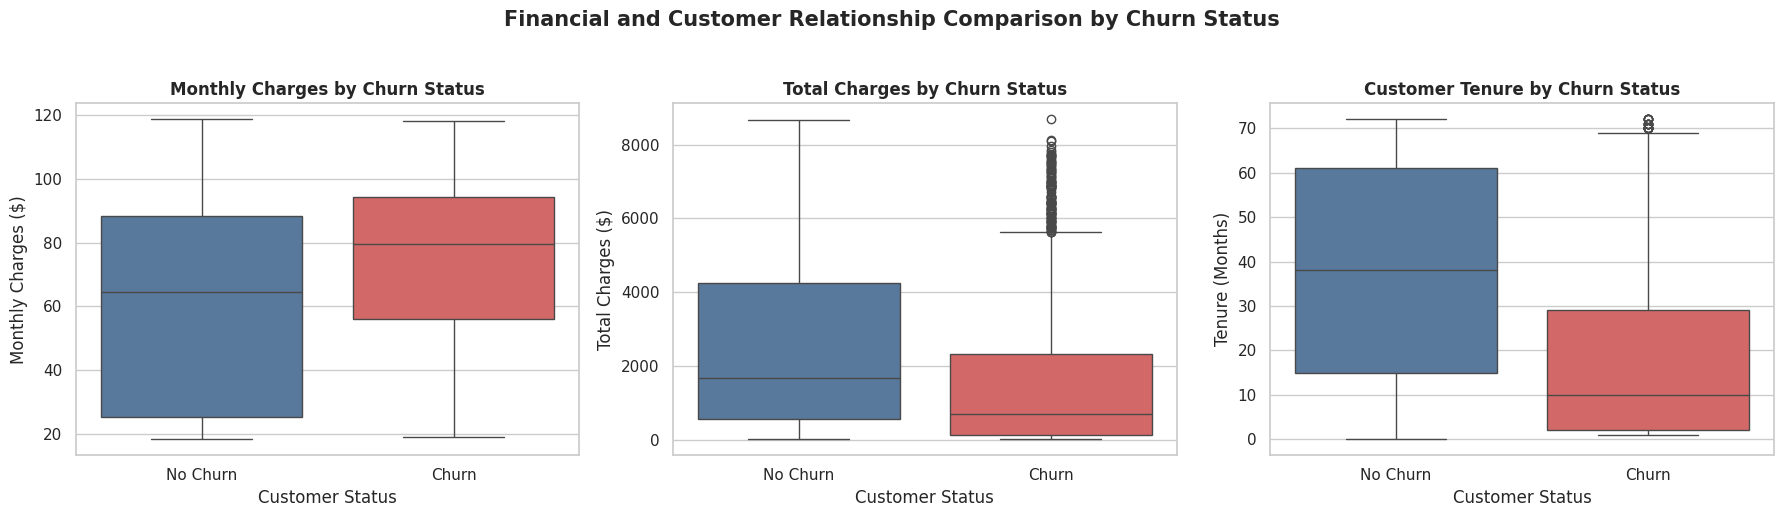

In [58]:
# ============================================================
# STEP 12: COMPARE MONTHLY CHARGES, TOTAL CHARGES, AND TENURE
# ============================================================

# Create three side-by-side boxplots.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------------------------------------------
# Boxplot 1: Monthly Charges by Churn Status
# ------------------------------------------------------------
sns.boxplot(
    data=eda_data,
    x="ChurnStatus",
    y="MonthlyCharges",
    hue="ChurnStatus",
    palette={
        "No Churn": "#4C78A8",
        "Churn": "#E45756"
    },
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Monthly Charges by Churn Status",
    fontweight="bold"
)
axes[0].set_xlabel("Customer Status")
axes[0].set_ylabel("Monthly Charges ($)")

# ------------------------------------------------------------
# Boxplot 2: Total Charges by Churn Status
# ------------------------------------------------------------
sns.boxplot(
    data=eda_data,
    x="ChurnStatus",
    y="TotalCharges",
    hue="ChurnStatus",
    palette={
        "No Churn": "#4C78A8",
        "Churn": "#E45756"
    },
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Total Charges by Churn Status",
    fontweight="bold"
)
axes[1].set_xlabel("Customer Status")
axes[1].set_ylabel("Total Charges ($)")

# ------------------------------------------------------------
# Boxplot 3: Tenure by Churn Status
# ------------------------------------------------------------
sns.boxplot(
    data=eda_data,
    x="ChurnStatus",
    y="tenure",
    hue="ChurnStatus",
    palette={
        "No Churn": "#4C78A8",
        "Churn": "#E45756"
    },
    legend=False,
    ax=axes[2]
)

axes[2].set_title(
    "Customer Tenure by Churn Status",
    fontweight="bold"
)
axes[2].set_xlabel("Customer Status")
axes[2].set_ylabel("Tenure (Months)")

plt.suptitle(
    "Financial and Customer Relationship Comparison by Churn Status",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### STEP 13: DIFFERENCES BETWEEN CHURNED AND RETAINED CUSTOMERS


In [59]:
# ============================================================
# STEP 13: DIFFERENCES BETWEEN CHURNED AND RETAINED CUSTOMERS
# ============================================================

# Convert the financial summary table into an index by churn status.
financial_comparison = financial_churn_summary.set_index(
    "ChurnStatus"
)

# Calculate differences using:
# Churn value minus No Churn value.
comparison_results = pd.DataFrame({
    "Metric": [
        "Average Monthly Charges",
        "Average Total Charges",
        "Average Tenure"
    ],
    "No Churn": [
        financial_comparison.loc["No Churn", "Average_Monthly_Charges"],
        financial_comparison.loc["No Churn", "Average_Total_Charges"],
        financial_comparison.loc["No Churn", "Average_Tenure"]
    ],
    "Churn": [
        financial_comparison.loc["Churn", "Average_Monthly_Charges"],
        financial_comparison.loc["Churn", "Average_Total_Charges"],
        financial_comparison.loc["Churn", "Average_Tenure"]
    ]
})

comparison_results["Difference (Churn - No Churn)"] = (
    comparison_results["Churn"] -
    comparison_results["No Churn"]
).round(2)

print("Comparison of Churned vs. Retained Customers:")
display(comparison_results)

Comparison of Churned vs. Retained Customers:


,Metric,No Churn,Churn,Difference (Churn - No Churn)
0,Average Monthly Charges,61.27,74.44,13.17
1,Average Total Charges,2555.34,1531.80,-1023.54
2,Average Tenure,37.57,17.98,-19.59


### STEP 14: CHURN BY DEMOGRAPHICS AND PAPERLESS BILLING


In [60]:
# ============================================================
# STEP 14: CHURN BY DEMOGRAPHICS AND PAPERLESS BILLING
# ============================================================

# ------------------------------------------------------------
# Select demographic and billing columns for analysis
# ------------------------------------------------------------
demographic_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PaperlessBilling"
]

# Create an empty list to store results.
demographic_churn_results = []

# ------------------------------------------------------------
# Calculate churn summaries for each selected column
# ------------------------------------------------------------
for column in demographic_columns:

    # Group customers by the selected demographic or billing category.
    summary = (
        eda_data
        .groupby(column, observed=False)
        .agg(
            Total_Customers=("Churn", "count"),
            Churned_Customers=("Churn", "sum"),
            Churn_Rate=("Churn", "mean")
        )
        .reset_index()
    )

    # Rename the category column so all outputs can be combined.
    summary = summary.rename(
        columns={column: "Category"}
    )

    # Convert SeniorCitizen values into readable labels.
    if column == "SeniorCitizen":
        summary["Category"] = summary["Category"].map({
            0: "Not Senior Citizen",
            1: "Senior Citizen"
        })

    # Add the name of the analysis variable.
    summary["Variable"] = column

    # Convert churn rate to percentage.
    summary["Churn_Rate"] = (
        summary["Churn_Rate"] * 100
    ).round(2)

    # Add result to the list.
    demographic_churn_results.append(summary)

# ------------------------------------------------------------
# Combine all results into one summary table
# ------------------------------------------------------------
demographic_churn_summary = pd.concat(
    demographic_churn_results,
    ignore_index=True
)

# Organize the columns for easier reading.
demographic_churn_summary = demographic_churn_summary[
    [
        "Variable",
        "Category",
        "Total_Customers",
        "Churned_Customers",
        "Churn_Rate"
    ]
]

print("Churn Summary by Demographic and Billing Segments:")
display(demographic_churn_summary)

Churn Summary by Demographic and Billing Segments:


,Variable,Category,Total_Customers,Churned_Customers,Churn_Rate
0,gender,Female,3488,939,26.92
1,gender,Male,3555,930,26.16
2,SeniorCitizen,Not Senior Citizen,5901,1393,23.61
3,SeniorCitizen,Senior Citizen,1142,476,41.68
4,Partner,No,3641,1200,32.96
5,Partner,Yes,3402,669,19.66
6,Dependents,No,4933,1543,31.28
7,Dependents,Yes,2110,326,15.45
8,PaperlessBilling,No,2872,469,16.33
9,PaperlessBilling,Yes,4171,1400,33.57


### STEP 15: VISUALIZE DEMOGRAPHIC AND BILLING CHURN RATES


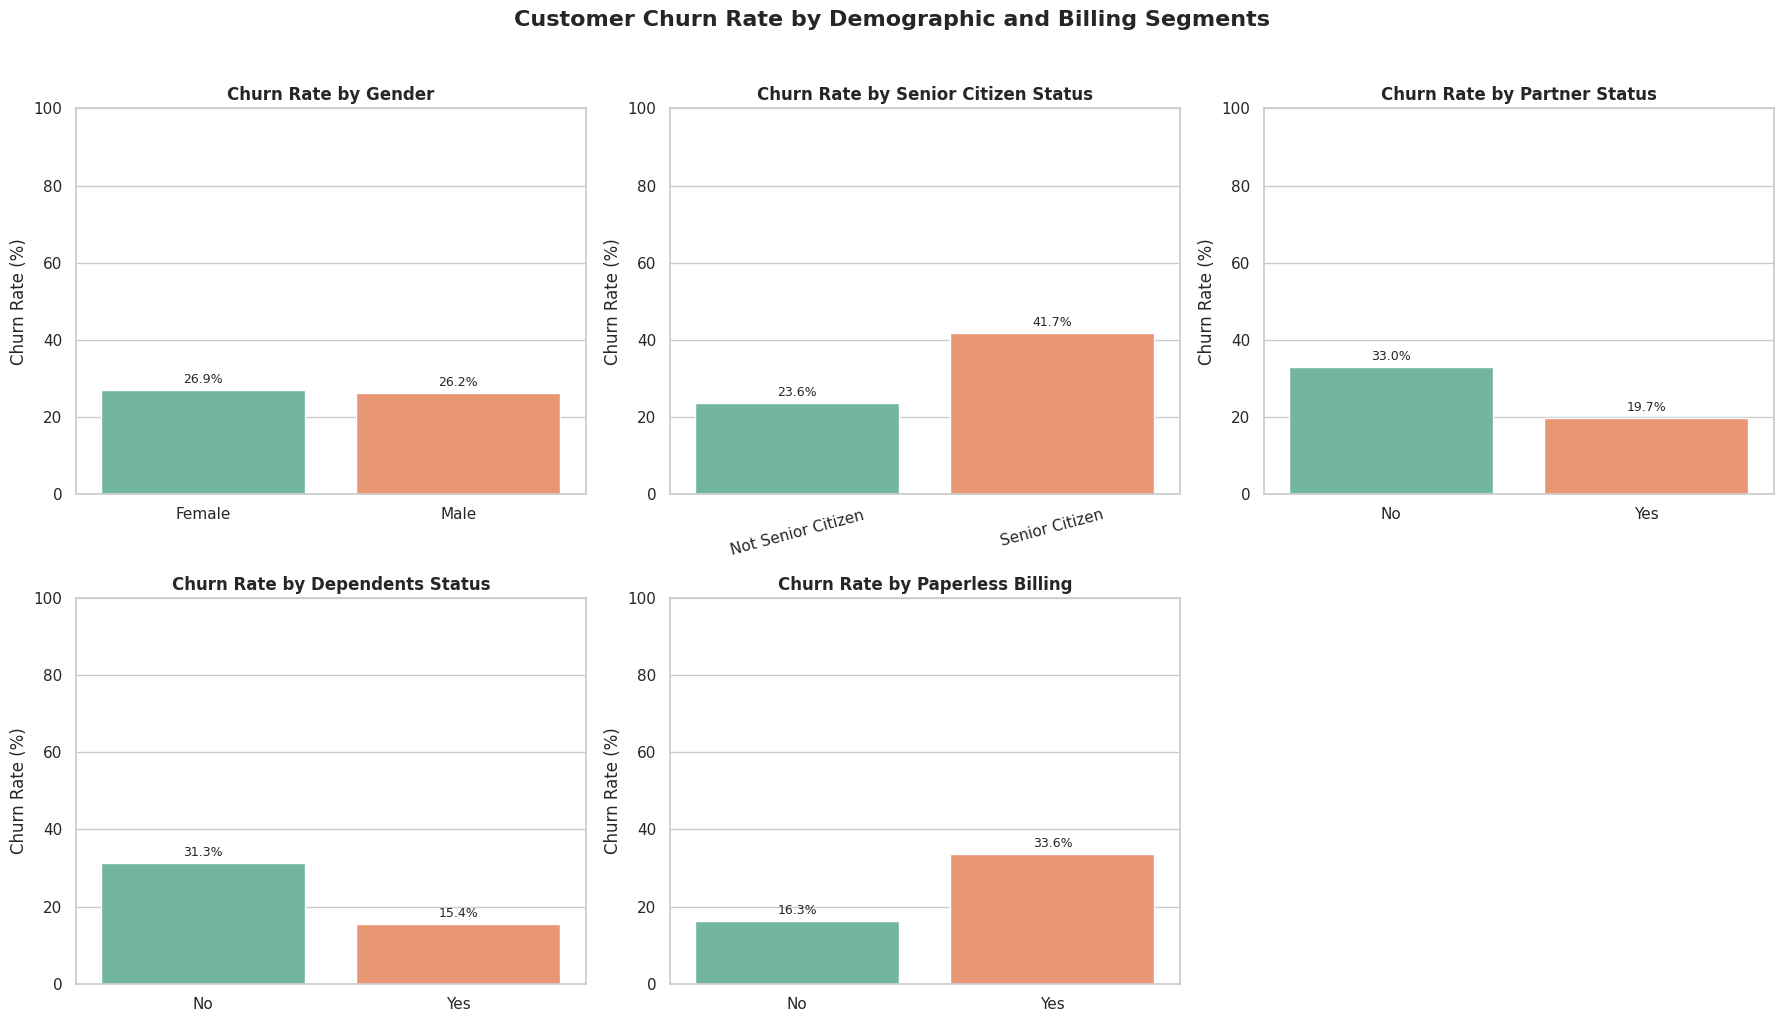

In [61]:
# ============================================================
# STEP 15: VISUALIZE DEMOGRAPHIC AND BILLING CHURN RATES
# ============================================================

# Create five charts in one figure.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten the 2x3 chart layout into a one-dimensional list.
axes = axes.flatten()

# Use readable titles for each chart.
chart_titles = {
    "gender": "Churn Rate by Gender",
    "SeniorCitizen": "Churn Rate by Senior Citizen Status",
    "Partner": "Churn Rate by Partner Status",
    "Dependents": "Churn Rate by Dependents Status",
    "PaperlessBilling": "Churn Rate by Paperless Billing"
}

# Create one bar chart for each variable.
for i, column in enumerate(demographic_columns):

    # Select summary results for one variable.
    chart_data = demographic_churn_summary[
        demographic_churn_summary["Variable"] == column
    ]

    # Create bar chart.
    ax = sns.barplot(
        data=chart_data,
        x="Category",
        y="Churn_Rate",
        hue="Category",
        palette="Set2",
        legend=False,
        ax=axes[i]
    )

    # Add title and labels.
    axes[i].set_title(
        chart_titles[column],
        fontweight="bold"
    )
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_ylim(0, 100)

    # Rotate labels only for senior-citizen chart.
    if column == "SeniorCitizen":
        axes[i].tick_params(
            axis="x",
            rotation=15
        )

    # Add percentages above each bar.
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

# Remove the unused sixth chart.
fig.delaxes(axes[5])

# Add one title for the whole chart group.
plt.suptitle(
    "Customer Churn Rate by Demographic and Billing Segments",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## STEP 16: IDENTIFY HIGHEST-CHURN DEMOGRAPHIC SEGMENTS


In [62]:
# ============================================================
# STEP 16: IDENTIFY HIGHEST-CHURN DEMOGRAPHIC SEGMENTS
# ============================================================

# For each demographic or billing variable, find the category
# with the highest churn rate.
highest_churn_segments = (
    demographic_churn_summary
    .sort_values(
        by=["Variable", "Churn_Rate"],
        ascending=[True, False]
    )
    .groupby("Variable", as_index=False)
    .first()
)

# Sort all highest-risk segments from highest to lowest churn rate.
highest_churn_segments = highest_churn_segments.sort_values(
    by="Churn_Rate",
    ascending=False
)

print("Highest-Churn Segment for Each Demographic or Billing Variable:")
display(highest_churn_segments)

Highest-Churn Segment for Each Demographic or Billing Variable:


,Variable,Category,Total_Customers,Churned_Customers,Churn_Rate
3,SeniorCitizen,Senior Citizen,1142,476,41.68
1,PaperlessBilling,Yes,4171,1400,33.57
2,Partner,No,3641,1200,32.96
0,Dependents,No,4933,1543,31.28
4,gender,Female,3488,939,26.92


## STEP 17: NUMERIC CORRELATION HEATMAP


Correlation Matrix:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.00,0.02,0.22,0.10,0.15
tenure,0.02,1.00,0.25,0.83,-0.35
MonthlyCharges,0.22,0.25,1.00,0.65,0.19
TotalCharges,0.10,0.83,0.65,1.00,-0.20
Churn,0.15,-0.35,0.19,-0.20,1.00


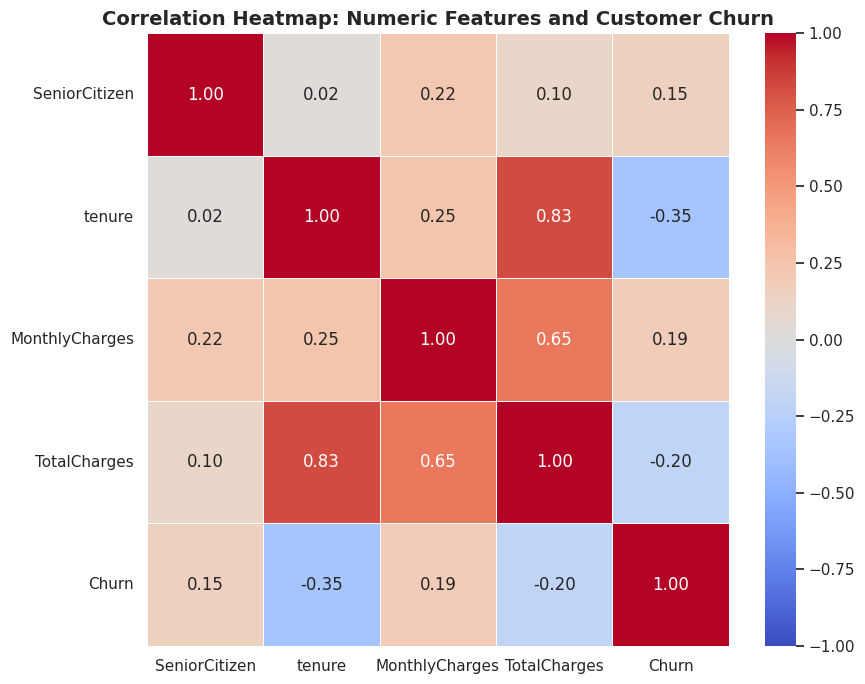

In [63]:
# ============================================================
# STEP 17: NUMERIC CORRELATION HEATMAP
# ============================================================

# Select the numeric columns most relevant to churn analysis.
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

# Create correlation matrix.
correlation_matrix = eda_data[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

# Create heatmap.
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Correlation Heatmap: Numeric Features and Customer Churn",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### STEP 18: CORRELATION OF NUMERIC FEATURES WITH CHURN


In [64]:
# ============================================================
# STEP 18: CORRELATION OF NUMERIC FEATURES WITH CHURN
# ============================================================

# Select only correlations with the Churn target.
churn_correlations = (
    correlation_matrix["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
    .reset_index()
)

# Rename columns for readability.
churn_correlations.columns = [
    "Feature",
    "Correlation_With_Churn"
]

# Round correlation results.
churn_correlations["Correlation_With_Churn"] = (
    churn_correlations["Correlation_With_Churn"]
    .round(3)
)

print("Numeric Feature Correlation with Customer Churn:")
display(churn_correlations)

Numeric Feature Correlation with Customer Churn:


,Feature,Correlation_With_Churn
0,MonthlyCharges,0.193
1,SeniorCitizen,0.151
2,TotalCharges,-0.199
3,tenure,-0.352


# PART:2

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
# ============================================================
# PART 2 - STEP 2: DEFINE FEATURES AND TARGET VARIABLE
# ============================================================

# ------------------------------------------------------------
# Define X: Input features for the machine learning models
# ------------------------------------------------------------
# Drop Churn because it is the target variable.
# Drop customerID because it is a unique identifier and does not
# represent useful customer behavior for prediction.
X = data.drop(columns=["Churn", "customerID"])

# ------------------------------------------------------------
# Define y: Target variable
# ------------------------------------------------------------
# Churn was already converted:
# 0 = Customer did not churn
# 1 = Customer churned
y = data["Churn"]

# ------------------------------------------------------------
# Confirm the feature and target structure
# ------------------------------------------------------------
print("Feature Matrix (X) Shape:", X.shape)
print("Target Variable (y) Shape:", y.shape)

print("\nFeature Columns:")
display(pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values
}))

print("\nTarget Distribution:")
display(
    y.value_counts()
    .sort_index()
    .rename(index={0: "No Churn", 1: "Churn"})
    .to_frame(name="Customer Count")
)

Feature Matrix (X) Shape: (7043, 19)
Target Variable (y) Shape: (7043,)

Feature Columns:


,Feature,Data Type
0,gender,object
1,SeniorCitizen,int64
2,Partner,object
3,Dependents,object
4,tenure,int64
5,PhoneService,object
6,MultipleLines,object
7,InternetService,object
8,OnlineSecurity,object
9,OnlineBackup,object



Target Distribution:


,Customer Count
Churn,
No Churn,5174
Churn,1869


In [67]:
# ============================================================
# PART 2 - STEP 3: IDENTIFY NUMERIC AND CATEGORICAL FEATURES
# ============================================================

# Numeric features are already stored as integer or float values.
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical features are stored as object/text values.
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nNumber of Numeric Features:", len(numeric_features))

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Categorical Features:", len(categorical_features))

print("\nTotal Features:")
print(len(numeric_features) + len(categorical_features))

Numeric Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Number of Numeric Features: 4

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of Categorical Features: 15

Total Features:
19


In [68]:
# ============================================================
# PART 2 - STEP 4: CREATE STRATIFIED TRAIN-TEST SPLIT
# ============================================================

# Split the dataset:
# 80% for training models and 20% for final testing.
#
# stratify=y keeps the churn proportion similar in training and testing data.
# random_state=42 ensures the split can be reproduced.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Display training and testing shapes
# ------------------------------------------------------------
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

# ------------------------------------------------------------
# Compare churn distribution across the full dataset,
# training dataset, and testing dataset
# ------------------------------------------------------------
churn_distribution_comparison = pd.DataFrame({
    "Full Dataset (%)": (y.value_counts(normalize=True).sort_index() * 100),
    "Training Set (%)": (y_train.value_counts(normalize=True).sort_index() * 100),
    "Testing Set (%)": (y_test.value_counts(normalize=True).sort_index() * 100)
})

# Rename 0 and 1 into business-friendly labels.
churn_distribution_comparison.index = [
    "No Churn",
    "Churn"
]

# Round percentages for display.
churn_distribution_comparison = churn_distribution_comparison.round(2)

print("\nChurn Distribution Comparison:")
display(churn_distribution_comparison)

# ------------------------------------------------------------
# Confirm that no preprocessing has been performed yet
# ------------------------------------------------------------
print("\nImportant:")
print("The training and test data have been separated.")
print("Encoding, scaling, imputation, and SMOTE will be applied later")
print("inside the machine-learning pipeline using training data only.")

Training Feature Shape: (5634, 19)
Testing Feature Shape: (1409, 19)

Training Target Shape: (5634,)
Testing Target Shape: (1409,)

Churn Distribution Comparison:


,Full Dataset (%),Training Set (%),Testing Set (%)
No Churn,73.46,73.46,73.46
Churn,26.54,26.54,26.54



Important:
The training and test data have been separated.
Encoding, scaling, imputation, and SMOTE will be applied later
inside the machine-learning pipeline using training data only.


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [70]:
# ============================================================
# PART 2 - STEP 5: BUILD PREPROCESSING PIPELINE
# ============================================================

# ------------------------------------------------------------
# Numeric preprocessing pipeline
# ------------------------------------------------------------
# IterativeImputer estimates missing numeric values using patterns
# from the other numeric features.
#
# StandardScaler standardizes numeric columns so they have
# a mean close to 0 and a standard deviation close to 1.
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            IterativeImputer(
                random_state=42
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ------------------------------------------------------------
# Categorical preprocessing pipeline
# ------------------------------------------------------------
# SimpleImputer fills missing category values using the most
# frequently occurring category in that feature.
#
# OneHotEncoder converts text categories into numeric columns.
# handle_unknown="ignore" prevents errors if a new category
# appears in test data or future data.
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# ------------------------------------------------------------
# Combine numeric and categorical preprocessing
# ------------------------------------------------------------
# ColumnTransformer applies numeric preprocessing only to numeric_features
# and categorical preprocessing only to categorical_features.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Preprocessing pipeline created successfully.

Numeric Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [71]:
# ============================================================
# PART 2 - STEP 6: TEST THE PREPROCESSING PIPELINE
# ============================================================

# Fit the preprocessing pipeline using training data only.
# This prevents information from the test set from influencing
# imputation, scaling, or encoding.
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test set using the already fitted pipeline.
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")

print("\nOriginal Training Data Shape:", X_train.shape)
print("Processed Training Data Shape:", X_train_processed.shape)

print("\nOriginal Testing Data Shape:", X_test.shape)
print("Processed Testing Data Shape:", X_test_processed.shape)

# Display the number of features generated after one-hot encoding.
print(
    "\nNumber of Features After Preprocessing:",
    X_train_processed.shape[1]
)

Preprocessing completed successfully.

Original Training Data Shape: (5634, 19)
Processed Training Data Shape: (5634, 45)

Original Testing Data Shape: (1409, 19)
Processed Testing Data Shape: (1409, 45)

Number of Features After Preprocessing: 45



Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training XGBoost...

BASELINE MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Logistic Regression,0.737,0.503,0.794,0.616,0.840,0.628
1,Random Forest,0.768,0.566,0.540,0.553,0.819,0.591
2,XGBoost,0.782,0.591,0.583,0.587,0.818,0.610
3,Decision Tree,0.717,0.470,0.532,0.499,0.658,0.375


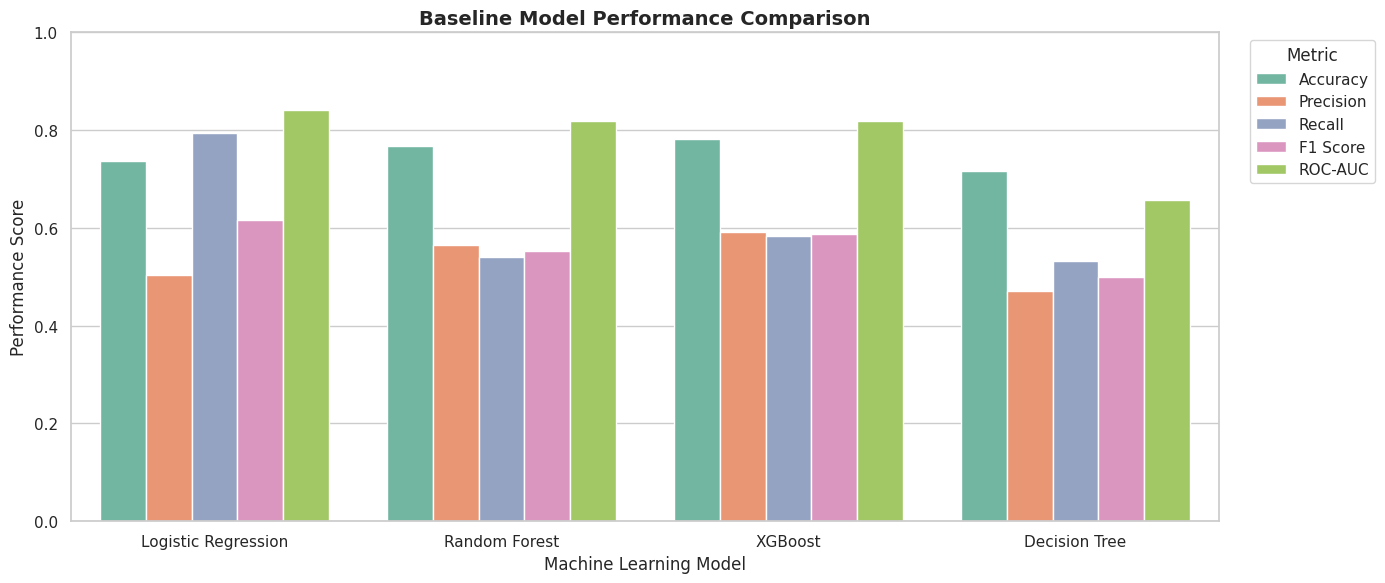


BEST BASELINE MODEL
Model: Logistic Regression
ROC-AUC: 0.840
Recall: 0.794
F1 Score: 0.616
Accuracy: 0.737

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



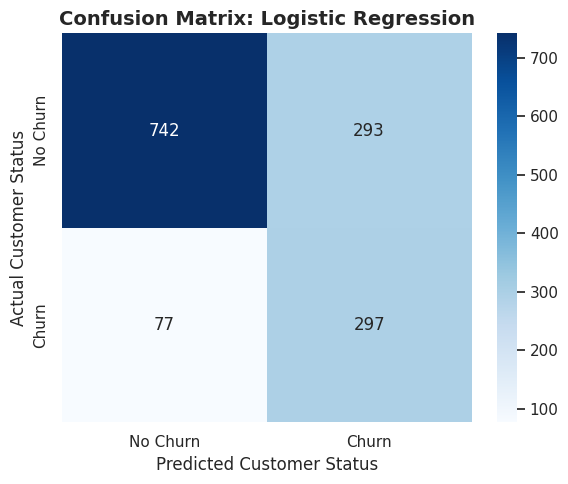

In [72]:
# ============================================================
# PART 2 - STEPS 6 TO 8:
# SMOTE, BASELINE MODEL TRAINING, EVALUATION, AND COMPARISON
# ============================================================

# Install packages if they are not already available in Colab.
!pip -q install imbalanced-learn xgboost

# ------------------------------------------------------------
# Import machine learning libraries
# ------------------------------------------------------------
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Create model pipelines
# ------------------------------------------------------------
# Each pipeline follows this order:
# 1. Preprocess numeric and categorical features
# 2. Apply SMOTE to training data only
# 3. Train the selected classification model
models = {
    "Logistic Regression": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42
                )
            )
        ]
    ),

    "Decision Tree": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            (
                "model",
                DecisionTreeClassifier(
                    random_state=42
                )
            )
        ]
    ),

    "Random Forest": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            (
                "model",
                RandomForestClassifier(
                    random_state=42,
                    n_estimators=300,
                    n_jobs=-1
                )
            )
        ]
    ),

    "XGBoost": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            (
                "model",
                XGBClassifier(
                    random_state=42,
                    eval_metric="logloss",
                    n_jobs=-1
                )
            )
        ]
    )
}

# ------------------------------------------------------------
# Train and evaluate all baseline models
# ------------------------------------------------------------
model_results = []
trained_models = {}

for model_name, model_pipeline in models.items():

    print(f"\nTraining {model_name}...")

    # Fit model using training data only.
    model_pipeline.fit(X_train, y_train)

    # Create churn predictions and churn probabilities on untouched test data.
    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    # Save trained pipeline for later evaluation and tuning comparison.
    trained_models[model_name] = model_pipeline

    # Save performance metrics.
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Average Precision": average_precision_score(y_test, y_prob)
    })

# ------------------------------------------------------------
# Create model comparison table
# ------------------------------------------------------------
baseline_results = (
    pd.DataFrame(model_results)
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("BASELINE MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(
    baseline_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Average Precision": "{:.3f}"
    })
)

# ------------------------------------------------------------
# Create baseline model performance chart
# ------------------------------------------------------------
comparison_chart_data = baseline_results.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=comparison_chart_data,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title(
    "Baseline Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Machine Learning Model")
plt.ylabel("Performance Score")
plt.ylim(0, 1)
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display best baseline model based on ROC-AUC
# ------------------------------------------------------------
best_baseline_model_name = baseline_results.iloc[0]["Model"]
best_baseline_model = trained_models[best_baseline_model_name]

best_baseline_metrics = baseline_results.iloc[0]

print("\n" + "=" * 70)
print("BEST BASELINE MODEL")
print("=" * 70)

print(f"Model: {best_baseline_model_name}")
print(f"ROC-AUC: {best_baseline_metrics['ROC-AUC']:.3f}")
print(f"Recall: {best_baseline_metrics['Recall']:.3f}")
print(f"F1 Score: {best_baseline_metrics['F1 Score']:.3f}")
print(f"Accuracy: {best_baseline_metrics['Accuracy']:.3f}")

# ------------------------------------------------------------
# Display classification report and confusion matrix
# for the best baseline model
# ------------------------------------------------------------
best_y_pred = best_baseline_model.predict(X_test)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_y_pred,
        target_names=["No Churn", "Churn"]
    )
)

best_confusion_matrix = confusion_matrix(
    y_test,
    best_y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    best_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    f"Confusion Matrix: {best_baseline_model_name}",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Predicted Customer Status")
plt.ylabel("Actual Customer Status")
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# PART 2 - STEPS 9 TO 11:
# GRIDSEARCHCV, TUNED MODEL EVALUATION, AND FINAL MODEL SELECTION
# ============================================================

# ------------------------------------------------------------
# Import hyperparameter-tuning library
# ------------------------------------------------------------
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# ------------------------------------------------------------
# Create 5-fold stratified cross-validation strategy
# ------------------------------------------------------------
# StratifiedKFold keeps the churn ratio similar in every fold.
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# Create Random Forest pipeline
# ------------------------------------------------------------
# The pipeline includes preprocessing and SMOTE so that every
# cross-validation fold preprocesses and resamples only its training portion.
random_forest_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# ------------------------------------------------------------
# Define Random Forest hyperparameter search grid
# ------------------------------------------------------------
rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

# ------------------------------------------------------------
# Create XGBoost pipeline
# ------------------------------------------------------------
xgboost_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

# ------------------------------------------------------------
# Define XGBoost hyperparameter search grid
# ------------------------------------------------------------
xgb_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.03, 0.10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# ------------------------------------------------------------
# Create GridSearchCV objects
# ------------------------------------------------------------
# scoring="roc_auc" means models are selected using ROC-AUC.
# n_jobs=-1 uses all available CPU cores.
rf_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

xgb_grid_search = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------------------------
# Run Random Forest GridSearchCV
# ------------------------------------------------------------
print("=" * 70)
print("TUNING RANDOM FOREST WITH 5-FOLD GRIDSEARCHCV")
print("=" * 70)

rf_grid_search.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(rf_grid_search.best_params_)

print(
    f"\nBest Random Forest Cross-Validation ROC-AUC: "
    f"{rf_grid_search.best_score_:.4f}"
)

# ------------------------------------------------------------
# Run XGBoost GridSearchCV
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("TUNING XGBOOST WITH 5-FOLD GRIDSEARCHCV")
print("=" * 70)

xgb_grid_search.fit(X_train, y_train)

print("\nBest XGBoost Parameters:")
print(xgb_grid_search.best_params_)

print(
    f"\nBest XGBoost Cross-Validation ROC-AUC: "
    f"{xgb_grid_search.best_score_:.4f}"
)

# ------------------------------------------------------------
# Evaluate tuned models on untouched test data
# ------------------------------------------------------------
tuned_models = {
    "Tuned Random Forest": rf_grid_search.best_estimator_,
    "Tuned XGBoost": xgb_grid_search.best_estimator_
}

tuned_model_results = []

for model_name, tuned_model in tuned_models.items():

    # Predict final churn class and churn probability.
    y_pred = tuned_model.predict(X_test)
    y_prob = tuned_model.predict_proba(X_test)[:, 1]

    # Store evaluation results.
    tuned_model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Average Precision": average_precision_score(y_test, y_prob)
    })

# Create tuned-model comparison table.
tuned_results = (
    pd.DataFrame(tuned_model_results)
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TUNED MODEL PERFORMANCE ON TEST DATA")
print("=" * 70)

display(
    tuned_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Average Precision": "{:.3f}"
    })
)

# ------------------------------------------------------------
# Compare baseline and tuned models
# ------------------------------------------------------------
final_model_comparison = (
    pd.concat(
        [baseline_results, tuned_results],
        ignore_index=True
    )
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON: BASELINE VS. TUNED MODELS")
print("=" * 70)

display(
    final_model_comparison.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Average Precision": "{:.3f}"
    })
)

# ------------------------------------------------------------
# Select final model based on highest test ROC-AUC
# ------------------------------------------------------------
best_final_model_name = final_model_comparison.iloc[0]["Model"]

# Select the matching trained model object.
if best_final_model_name in tuned_models:
    final_model = tuned_models[best_final_model_name]
else:
    final_model = trained_models[best_final_model_name]

# Store final model metrics.
final_model_metrics = final_model_comparison.iloc[0]

print("\n" + "=" * 70)
print("FINAL SELECTED MODEL")
print("=" * 70)

print(f"Final Model: {best_final_model_name}")
print(f"Test ROC-AUC: {final_model_metrics['ROC-AUC']:.3f}")
print(f"Test Accuracy: {final_model_metrics['Accuracy']:.3f}")
print(f"Test Precision: {final_model_metrics['Precision']:.3f}")
print(f"Test Recall: {final_model_metrics['Recall']:.3f}")
print(f"Test F1 Score: {final_model_metrics['F1 Score']:.3f}")
print(
    f"Test Average Precision: "
    f"{final_model_metrics['Average Precision']:.3f}"
)

TUNING RANDOM FOREST WITH 5-FOLD GRIDSEARCHCV
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Random Forest Cross-Validation ROC-AUC: 0.8419

TUNING XGBOOST WITH 5-FOLD GRIDSEARCHCV
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best XGBoost Parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best XGBoost Cross-Validation ROC-AUC: 0.8471

TUNED MODEL PERFORMANCE ON TEST DATA


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Tuned XGBoost,0.775,0.559,0.727,0.632,0.843,0.648
1,Tuned Random Forest,0.762,0.542,0.676,0.602,0.836,0.632



FINAL MODEL COMPARISON: BASELINE VS. TUNED MODELS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Tuned XGBoost,0.775,0.559,0.727,0.632,0.843,0.648
1,Logistic Regression,0.737,0.503,0.794,0.616,0.840,0.628
2,Tuned Random Forest,0.762,0.542,0.676,0.602,0.836,0.632
3,Random Forest,0.768,0.566,0.540,0.553,0.819,0.591
4,XGBoost,0.782,0.591,0.583,0.587,0.818,0.610
5,Decision Tree,0.717,0.470,0.532,0.499,0.658,0.375



FINAL SELECTED MODEL
Final Model: Tuned XGBoost
Test ROC-AUC: 0.843
Test Accuracy: 0.775
Test Precision: 0.559
Test Recall: 0.727
Test F1 Score: 0.632
Test Average Precision: 0.648


FINAL MODEL CLASSIFICATION REPORT: Tuned XGBoost
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.73      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409

ROC-AUC Score: 0.843
Average Precision Score: 0.648


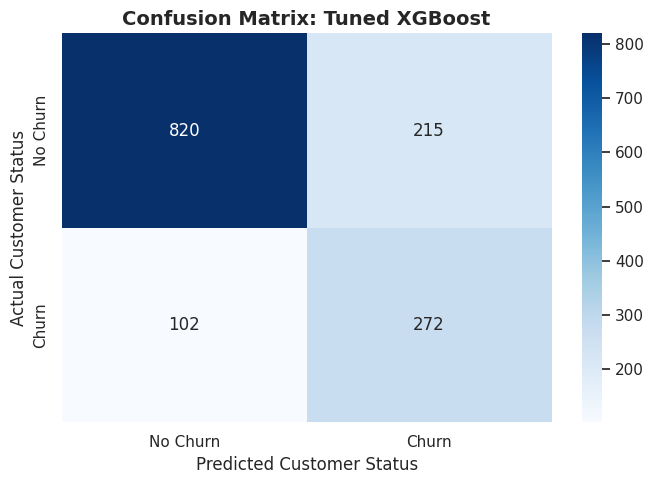

<Figure size 1000x800 with 0 Axes>

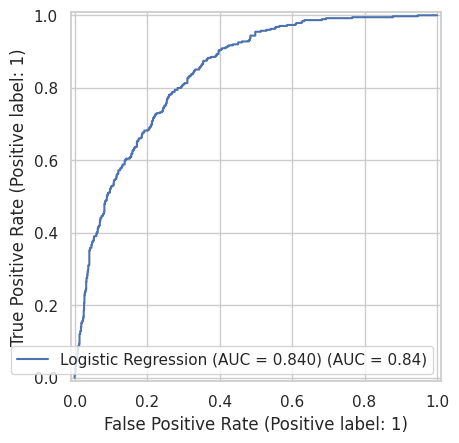

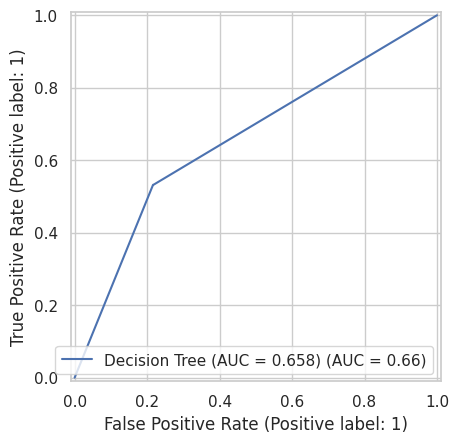

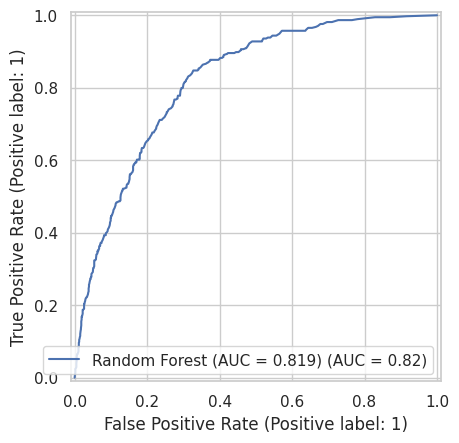

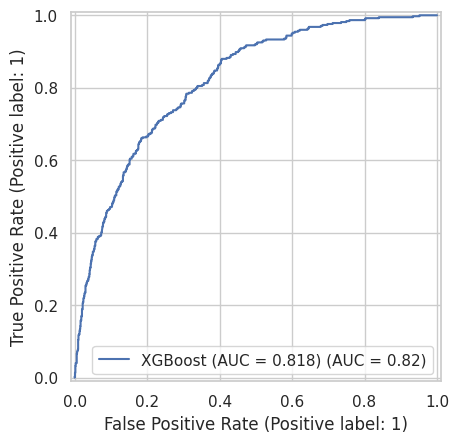

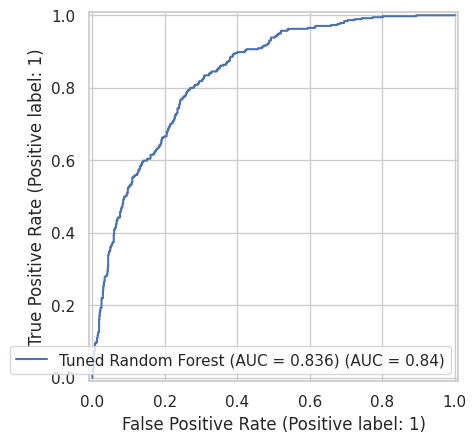

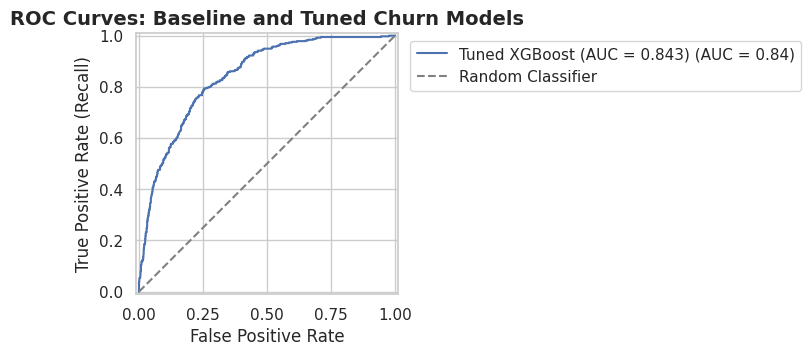

<Figure size 1000x800 with 0 Axes>

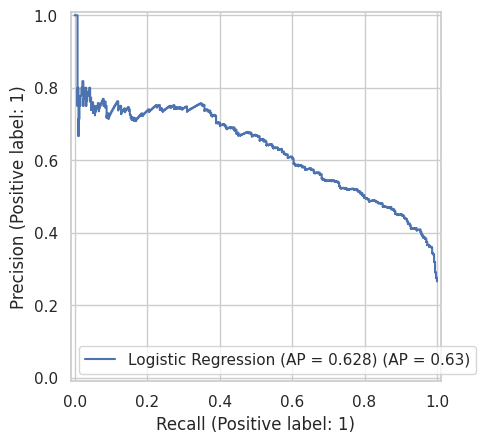

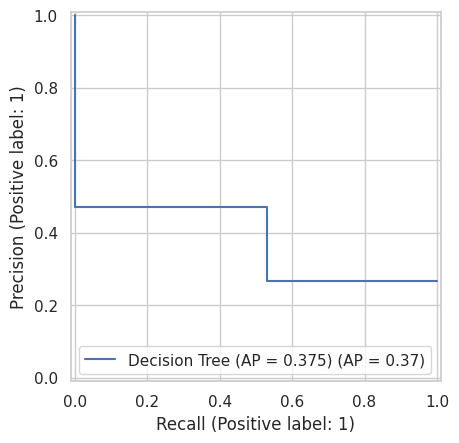

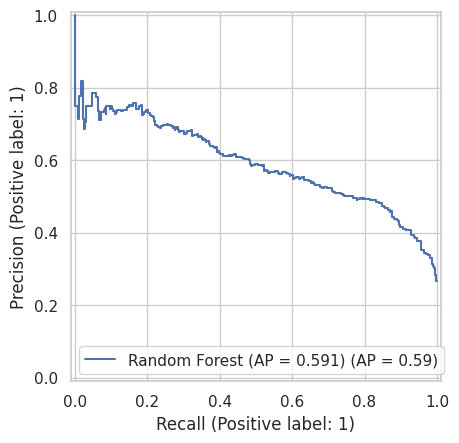

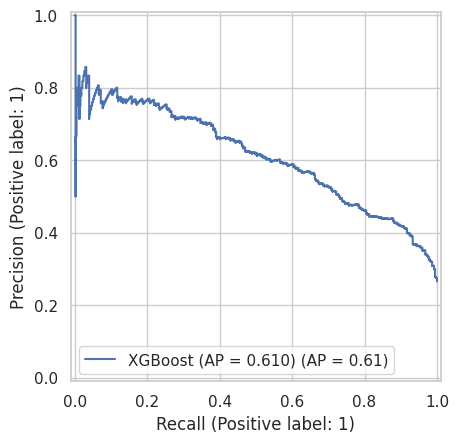

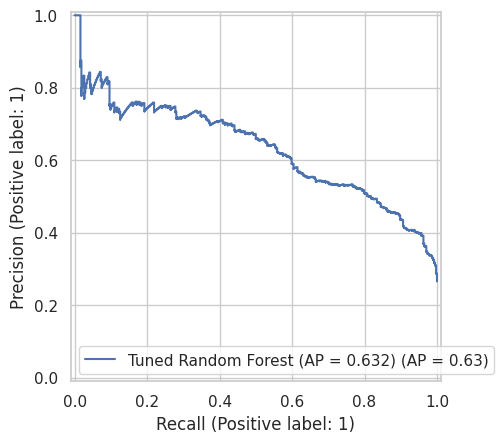

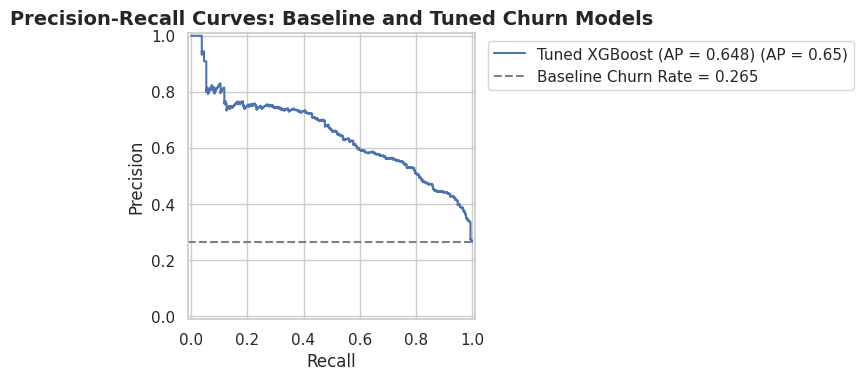


TOP 15 CUSTOMERS BY PREDICTED CHURN RISK


,customerID,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Status,Predicted_Status,Churn_Risk_Probability,Risk_Category
6866,0295-PPHDO,1,Month-to-month,Fiber optic,Electronic check,$95.45,$95.45,Churn,Churn,91.0%,High Risk
3380,5178-LMXOP,1,Month-to-month,Fiber optic,Electronic check,$95.10,$95.10,Churn,Churn,91.0%,High Risk
2797,6023-YEBUP,3,Month-to-month,Fiber optic,Electronic check,$100.95,$329.95,Churn,Churn,90.5%,High Risk
2631,6861-XWTWQ,7,Month-to-month,Fiber optic,Electronic check,$99.25,$665.45,Churn,Churn,90.5%,High Risk
4585,1069-XAIEM,1,Month-to-month,Fiber optic,Electronic check,$85.05,$85.05,Churn,Churn,90.4%,High Risk
6365,8884-ADFVN,7,Month-to-month,Fiber optic,Electronic check,$101.95,$700.85,Churn,Churn,90.2%,High Risk
642,0970-ETWGE,1,Month-to-month,Fiber optic,Electronic check,$89.55,$89.55,Churn,Churn,90.2%,High Risk
2397,3722-WPXTK,1,Month-to-month,Fiber optic,Electronic check,$88.35,$88.35,Churn,Churn,90.2%,High Risk
2464,2609-IAICY,1,Month-to-month,Fiber optic,Electronic check,$77.15,$77.15,Churn,Churn,90.0%,High Risk
3727,9057-SIHCH,3,Month-to-month,Fiber optic,Electronic check,$96.60,$291.90,Churn,Churn,90.0%,High Risk



Customer Count by Predicted Churn-Risk Category:


,Customer Count
Risk_Category,
Low Risk,705
Medium Risk,341
High Risk,363


In [74]:
# ============================================================
# PART 2 - STEPS 12 AND 13:
# FINAL MODEL EVALUATION, ROC CURVE, PR CURVE, AND RISK SCORES
# ============================================================

# ------------------------------------------------------------
# Import evaluation visualization libraries
# ------------------------------------------------------------
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# Prepare predictions from the selected final model
# ------------------------------------------------------------
final_y_pred = final_model.predict(X_test)
final_y_prob = final_model.predict_proba(X_test)[:, 1]

# Calculate final model evaluation values.
final_roc_auc = roc_auc_score(y_test, final_y_prob)
final_average_precision = average_precision_score(y_test, final_y_prob)

# ------------------------------------------------------------
# Print final classification report
# ------------------------------------------------------------
print("=" * 70)
print(f"FINAL MODEL CLASSIFICATION REPORT: {best_final_model_name}")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_y_pred,
        target_names=["No Churn", "Churn"]
    )
)

print(f"ROC-AUC Score: {final_roc_auc:.3f}")
print(f"Average Precision Score: {final_average_precision:.3f}")

# ------------------------------------------------------------
# Create final model confusion matrix
# ------------------------------------------------------------
final_confusion_matrix = confusion_matrix(
    y_test,
    final_y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    f"Confusion Matrix: {best_final_model_name}",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Predicted Customer Status")
plt.ylabel("Actual Customer Status")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Combine all baseline and tuned models for visual comparison
# ------------------------------------------------------------
all_evaluation_models = {
    **trained_models,
    **tuned_models
}

# ------------------------------------------------------------
# Create ROC curves for all models
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for model_name, model in all_evaluation_models.items():

    # Generate churn probabilities.
    model_probabilities = model.predict_proba(X_test)[:, 1]

    # Calculate ROC-AUC score for the chart label.
    model_auc = roc_auc_score(
        y_test,
        model_probabilities
    )

    # Create ROC curve.
    RocCurveDisplay.from_predictions(
        y_test,
        model_probabilities,
        name=f"{model_name} (AUC = {model_auc:.3f})"
    )

# Add random-classifier reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

plt.title(
    "ROC Curves: Baseline and Tuned Churn Models",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Create Precision-Recall curves for all models
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for model_name, model in all_evaluation_models.items():

    # Generate churn probabilities.
    model_probabilities = model.predict_proba(X_test)[:, 1]

    # Calculate average precision for chart label.
    model_average_precision = average_precision_score(
        y_test,
        model_probabilities
    )

    # Create precision-recall curve.
    PrecisionRecallDisplay.from_predictions(
        y_test,
        model_probabilities,
        name=(
            f"{model_name} "
            f"(AP = {model_average_precision:.3f})"
        )
    )

# Add baseline churn rate as a reference line.
baseline_churn_rate = y_test.mean()

plt.axhline(
    y=baseline_churn_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline Churn Rate = {baseline_churn_rate:.3f}"
)

plt.title(
    "Precision-Recall Curves: Baseline and Tuned Churn Models",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Create customer churn-risk score table
# ------------------------------------------------------------
# This table shows how a company could prioritize customers
# for retention outreach based on predicted probability.
risk_score_table = X_test.copy()

# Preserve original customer IDs for business follow-up.
risk_score_table["customerID"] = data.loc[
    X_test.index,
    "customerID"
]

# Add actual outcome for validation.
risk_score_table["Actual_Churn"] = y_test

# Add model prediction and predicted probability.
risk_score_table["Predicted_Churn"] = final_y_pred
risk_score_table["Churn_Risk_Probability"] = final_y_prob

# Convert numeric outputs into readable business labels.
risk_score_table["Actual_Status"] = risk_score_table[
    "Actual_Churn"
].map({
    0: "No Churn",
    1: "Churn"
})

risk_score_table["Predicted_Status"] = risk_score_table[
    "Predicted_Churn"
].map({
    0: "No Churn",
    1: "Churn"
})

# Create risk categories based on churn probability.
risk_score_table["Risk_Category"] = pd.cut(
    risk_score_table["Churn_Risk_Probability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

# Sort customers from highest to lowest predicted churn risk.
risk_score_table = risk_score_table.sort_values(
    by="Churn_Risk_Probability",
    ascending=False
)

# Show selected business-friendly columns.
high_risk_customer_preview = risk_score_table[
    [
        "customerID",
        "tenure",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges",
        "Actual_Status",
        "Predicted_Status",
        "Churn_Risk_Probability",
        "Risk_Category"
    ]
].head(15)

print("\n" + "=" * 70)
print("TOP 15 CUSTOMERS BY PREDICTED CHURN RISK")
print("=" * 70)

display(
    high_risk_customer_preview.style.format({
        "MonthlyCharges": "${:.2f}",
        "TotalCharges": "${:.2f}",
        "Churn_Risk_Probability": "{:.1%}"
    })
)

# ------------------------------------------------------------
# Display number of customers in each risk category
# ------------------------------------------------------------
risk_category_summary = (
    risk_score_table["Risk_Category"]
    .value_counts()
    .reindex([
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ])
    .fillna(0)
    .astype(int)
    .to_frame(name="Customer Count")
)

print("\nCustomer Count by Predicted Churn-Risk Category:")
display(risk_category_summary)

SHAP EXPLAINABILITY: Tuned XGBoost
SHAP values calculated successfully.
SHAP dataset shape: (1409, 45)


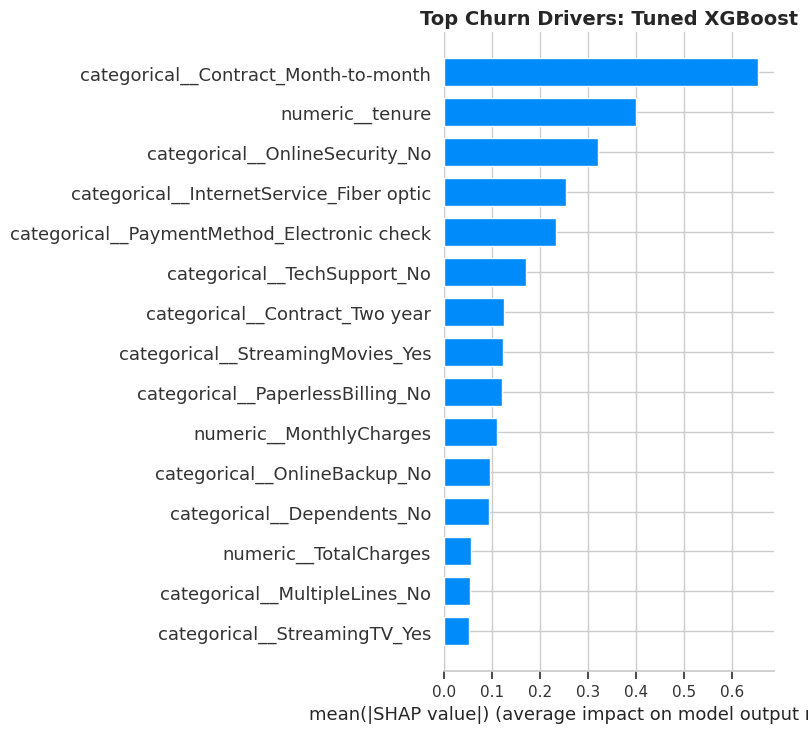

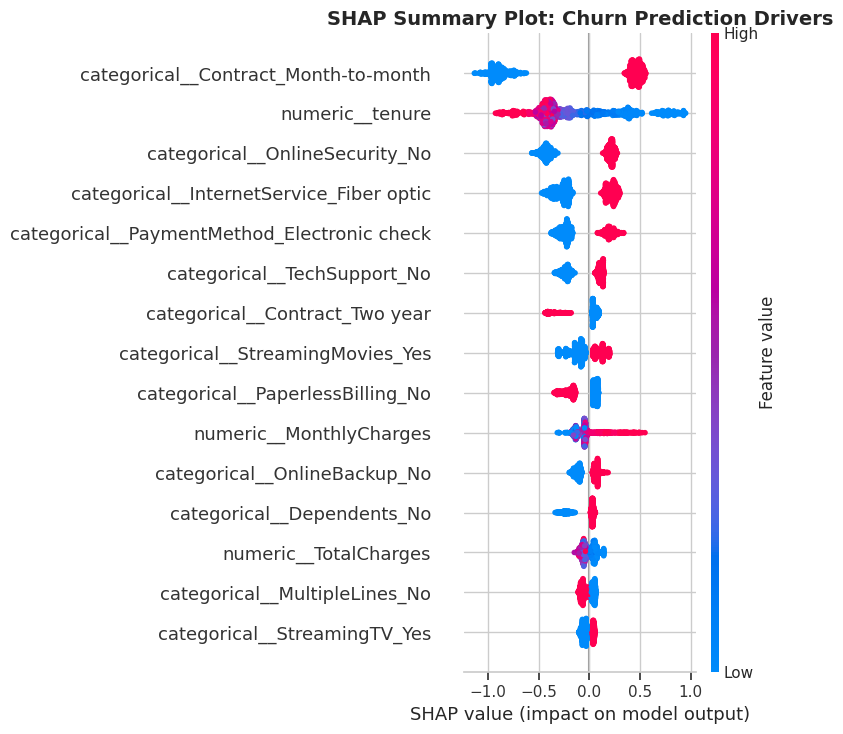


TOP FIVE CHURN DRIVERS FROM SHAP


,Feature,Mean_Absolute_SHAP_Value
0,Contract_Month-to-month,0.6545
1,tenure,0.3994
2,OnlineSecurity_No,0.3203
3,InternetService_Fiber optic,0.2527
4,PaymentMethod_Electronic check,0.2321



FINAL MODEL PERFORMANCE


,Final_Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision
0,Tuned XGBoost,0.775,0.559,0.727,0.632,0.843,0.648



PROJECT FILES SAVED SUCCESSFULLY
1. final_churn_prediction_model.joblib
2. model_comparison_results.csv
3. final_model_performance.csv
4. top_5_churn_drivers.csv
5. customer_churn_risk_scores.csv

BUSINESS RECOMMENDATIONS
1. Prioritize Month-to-month contract customers. This group had the highest observed churn rate of 42.71%.
2. Focus early-retention efforts on customers in the 0-12 Months tenure group, which had a churn rate of 47.44%.
3. Review the experience of customers using Electronic check, because this payment group had a churn rate of 45.29%.
4. Investigate service quality, pricing, and support for Fiber optic customers. This group had a churn rate of 41.89%.
5. Use Tuned XGBoost to rank customers by churn-risk probability and prioritize High Risk customers for retention outreach, service reviews, and personalized offers.

Important: These findings show data associations and model patterns. They should be validated with retention experiments, customer feedback, and business 

In [75]:
# ============================================================
# PART 2 - STEPS 14 AND 15:
# SHAP EXPLAINABILITY, TOP CHURN DRIVERS, EXPORTS, AND CONCLUSION
# ============================================================

# Install and import required libraries.
!pip -q install shap joblib

import os
import joblib
import shap

# ------------------------------------------------------------
# Confirm that the selected final model is tree-based
# ------------------------------------------------------------
tree_model_names = [
    "Random Forest",
    "XGBoost",
    "Tuned Random Forest",
    "Tuned XGBoost"
]

if best_final_model_name not in tree_model_names:
    raise ValueError(
        f"The selected final model is '{best_final_model_name}'. "
        "This SHAP cell is designed for Random Forest or XGBoost. "
        "Please use a model-specific SHAP cell instead."
    )

# ------------------------------------------------------------
# Extract preprocessing and trained tree classifier
# ------------------------------------------------------------
# final_model is the complete imblearn pipeline:
# preprocessor -> SMOTE -> trained classifier.
final_preprocessor = final_model.named_steps["preprocessor"]
final_classifier = final_model.named_steps["model"]

# ------------------------------------------------------------
# Transform the test data for SHAP
# ------------------------------------------------------------
# The preprocessor was already fitted on training data as part
# of the final model pipeline. We only transform X_test here.
X_test_transformed = final_preprocessor.transform(X_test)

# Get the names of all transformed features, including one-hot encoded columns.
transformed_feature_names = final_preprocessor.get_feature_names_out()

# Convert transformed test data into a readable DataFrame.
# .toarray() is used only if the transformed result is sparse.
if hasattr(X_test_transformed, "toarray"):
    X_test_shap = pd.DataFrame(
        X_test_transformed.toarray(),
        columns=transformed_feature_names,
        index=X_test.index
    )
else:
    X_test_shap = pd.DataFrame(
        X_test_transformed,
        columns=transformed_feature_names,
        index=X_test.index
    )

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------
# TreeExplainer is suitable for Random Forest and XGBoost models.
shap_explainer = shap.TreeExplainer(final_classifier)
shap_values = shap_explainer.shap_values(X_test_shap)

# Handle different SHAP output structures across versions/models.
# For binary classification, we need SHAP values for the Churn = 1 class.
if isinstance(shap_values, list):
    shap_values_for_churn = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_for_churn = shap_values[:, :, 1]
else:
    shap_values_for_churn = shap_values

print("=" * 70)
print(f"SHAP EXPLAINABILITY: {best_final_model_name}")
print("=" * 70)
print("SHAP values calculated successfully.")
print("SHAP dataset shape:", X_test_shap.shape)

# ------------------------------------------------------------
# SHAP global feature-importance bar chart
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_for_churn,
    X_test_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title(
    f"Top Churn Drivers: {best_final_model_name}",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SHAP summary beeswarm plot
# ------------------------------------------------------------
# Red values tend to push the prediction toward churn.
# Blue values tend to push the prediction away from churn.
plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values_for_churn,
    X_test_shap,
    max_display=15,
    show=False
)

plt.title(
    f"SHAP Summary Plot: Churn Prediction Drivers",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Create top-five churn-driver table
# ------------------------------------------------------------
shap_importance = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean_Absolute_SHAP_Value": np.abs(
        shap_values_for_churn
    ).mean(axis=0)
})

# Make transformed column names more readable.
shap_importance["Feature"] = (
    shap_importance["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

# Sort from most important to least important.
shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP_Value",
    ascending=False
).reset_index(drop=True)

top_5_churn_drivers = shap_importance.head(5).copy()

print("\n" + "=" * 70)
print("TOP FIVE CHURN DRIVERS FROM SHAP")
print("=" * 70)

display(
    top_5_churn_drivers.style.format({
        "Mean_Absolute_SHAP_Value": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Create a model-performance export table
# ------------------------------------------------------------
final_model_performance = pd.DataFrame([{
    "Final_Model": best_final_model_name,
    "Accuracy": final_model_metrics["Accuracy"],
    "Precision": final_model_metrics["Precision"],
    "Recall": final_model_metrics["Recall"],
    "F1_Score": final_model_metrics["F1 Score"],
    "ROC_AUC": final_model_metrics["ROC-AUC"],
    "Average_Precision": final_model_metrics["Average Precision"]
}])

print("\n" + "=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

display(
    final_model_performance.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1_Score": "{:.3f}",
        "ROC_AUC": "{:.3f}",
        "Average_Precision": "{:.3f}"
    })
)

# ------------------------------------------------------------
# Save model and project result files
# ------------------------------------------------------------
os.makedirs("project_outputs", exist_ok=True)

# Save final trained model pipeline.
joblib.dump(
    final_model,
    "project_outputs/final_churn_prediction_model.joblib"
)

# Save comparison and explainability tables.
final_model_comparison.to_csv(
    "project_outputs/model_comparison_results.csv",
    index=False
)

final_model_performance.to_csv(
    "project_outputs/final_model_performance.csv",
    index=False
)

top_5_churn_drivers.to_csv(
    "project_outputs/top_5_churn_drivers.csv",
    index=False
)

risk_score_table.to_csv(
    "project_outputs/customer_churn_risk_scores.csv",
    index=False
)

print("\n" + "=" * 70)
print("PROJECT FILES SAVED SUCCESSFULLY")
print("=" * 70)

print("1. final_churn_prediction_model.joblib")
print("2. model_comparison_results.csv")
print("3. final_model_performance.csv")
print("4. top_5_churn_drivers.csv")
print("5. customer_churn_risk_scores.csv")

# ------------------------------------------------------------
# Create data-driven business recommendations
# ------------------------------------------------------------
# Identify high-risk results from EDA tables already created.
highest_contract = contract_churn_summary.iloc[0]
highest_payment = payment_churn_summary.iloc[0]
highest_internet = internet_churn_summary.iloc[0]
highest_tenure = tenure_churn_summary.loc[
    tenure_churn_summary["Churn_Rate"].idxmax()
]

print("\n" + "=" * 70)
print("BUSINESS RECOMMENDATIONS")
print("=" * 70)

print(
    f"1. Prioritize {highest_contract['Contract']} contract customers. "
    f"This group had the highest observed churn rate of "
    f"{highest_contract['Churn_Rate']:.2f}%."
)

print(
    f"2. Focus early-retention efforts on customers in the "
    f"{highest_tenure['TenureGroup']} tenure group, which had a churn "
    f"rate of {highest_tenure['Churn_Rate']:.2f}%."
)

print(
    f"3. Review the experience of customers using "
    f"{highest_payment['PaymentMethod']}, because this payment group "
    f"had a churn rate of {highest_payment['Churn_Rate']:.2f}%."
)

print(
    f"4. Investigate service quality, pricing, and support for "
    f"{highest_internet['InternetService']} customers. This group had "
    f"a churn rate of {highest_internet['Churn_Rate']:.2f}%."
)

print(
    f"5. Use {best_final_model_name} to rank customers by churn-risk "
    f"probability and prioritize High Risk customers for retention "
    f"outreach, service reviews, and personalized offers."
)

print(
    "\nImportant: These findings show data associations and model "
    "patterns. They should be validated with retention experiments, "
    "customer feedback, and business monitoring before making "
    "large-scale policy changes."
)

In [76]:
print("Final model:", best_final_model_name)
print("Classifier type:", type(final_model.named_steps["model"]))
print("Preprocessor type:", type(final_model.named_steps["preprocessor"]))

Final model: Tuned XGBoost
Classifier type: <class 'xgboost.sklearn.XGBClassifier'>
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
